# QML Unified Benchmark — CIFAR-10 · v3 (PCA+LDA + PCE Encoding)
**BTP Project | 600 samples · 18 Encodings (17 + PCE) · 10-class CIFAR-10**

**v3 — adds Pauli Correlation Encoding (PCE) on 64-dim PCA features:**

| | v2 (LDA pipeline) | v3 (PCE added) |
|---|---|---|
| Standard encodings | PCA-50→LDA-8, 8 qubits | same |
| New encoding | — | **PCE: PCA-64→HEA(8q,8 layers)** |
| Feature dims (PCE) | — | **64** |
| PCE capacity | — | **C(8,2)×3²=252 ≥ 64  ✓** |

### Mathematical compatibility
```
PCE capacity:  m_max(n, k) = C(n, k) × 3^k
  n=8, k=2 → m_max = 252 ≥ 64  ✓  CAN ENCODE ALL 64 PCA FEATURES
HEA layers:  p = floor(64/8) = 8
Gate count:  8×7 CZ + 9×8 RY = 128 gates  (QAOA needs 42,000+)
Statevector: 2^8 = 256 amplitudes  (trivially fast)
PCA-64 variance ≈ 35-40% of CIFAR-10 RGB  (vs PCA-4 ≈ 5% in v1)
```

Two parallel preprocessing pipelines:
- **Pipeline A**: RGB → StandardScaler → PCA-50(whitened) → LDA-8 → MinMax[0,π] → 17 encodings
- **Pipeline B**: RGB → StandardScaler → PCA-64(whitened) → MinMax[0,π] → PCE HEA encoding


## 0a · Package Setup

In [1]:
import subprocess, sys

# LDA is in sklearn — no new dependencies needed
REQUIRED = ["pennylane", "pennylane-lightning", "scikit-learn", "matplotlib", "joblib", "pandas"]
OPTIONAL = ["tensorflow", "torch", "torchvision"]   # for CIFAR-10 loading

def _pip_install(pkg):
    try:
        __import__(pkg.replace("-", "_").split("==")[0])
        print(f"  [OK] {pkg} already installed")
        return True
    except ImportError:
        print(f"  [..] installing {pkg} ...")
        result = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                                capture_output=True, text=True)
        if result.returncode == 0:
            print(f"  [OK] {pkg} installed")
            return True
        else:
            print(f"  [FAIL] {pkg}: {result.stderr.strip()[:200]}")
            return False

print("Required packages:")
for p in REQUIRED: _pip_install(p)
print("\nOptional (CIFAR-10 loading):")
for p in OPTIONAL:
    ok = _pip_install(p)
    if not ok:
        print(f"     -> without {p}, will fall back to next tier")


Required packages:
  [OK] pennylane already installed
  [OK] pennylane-lightning already installed
  [..] installing scikit-learn ...
  [OK] scikit-learn installed
  [OK] matplotlib already installed
  [OK] joblib already installed
  [OK] pandas already installed

Optional (CIFAR-10 loading):
  [OK] tensorflow already installed
  [OK] torch already installed
  [OK] torchvision already installed


## 0b · Imports & Global Config

In [2]:
import warnings, time, itertools, os, math
from pathlib import Path
from itertools import combinations
from math import comb, floor
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pennylane as qml
from joblib import Parallel, delayed

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)

OUTPUT_DIR = Path.cwd() / "qml_outputs_cifar10_pce"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Figures will be saved to:", OUTPUT_DIR.resolve())

def get_device(n_qubits):
    try:
        return qml.device("lightning.qubit", wires=n_qubits)
    except Exception:
        return qml.device("default.qubit", wires=n_qubits)

print("Simulator backend:", get_device(2).name)
N_CORES = os.cpu_count() or 1
print(f"CPU cores detected: {N_CORES}")

# ── QUICK_TEST toggle ─────────────────────────────────────────────────────────
QUICK_TEST = False

if QUICK_TEST:
    N_SAMPLES    = 10
    N_QUBITS     = 4
    N_EPOCHS     = 6
    N_CLASSES    = 10
    PCA_DIMS     = [4, 8]
    QUBIT_SWEEP  = [2, 3, 4]
    PCA_PRENOISE = 20
    PCE_FEATURES = 16        # quick test: 16 features
    PCE_N_QUBITS = 4         # n=4, k=2 → m_max=54 ≥ 16  ✓
    PCE_K_ORDER  = 2
    print("\n*** QUICK_TEST = True ***")
else:
    N_SAMPLES    = 60
    N_QUBITS     = 8
    N_EPOCHS     = 30
    N_CLASSES    = 10
    PCA_DIMS     = [8, 16, 32, 64]
    QUBIT_SWEEP  = [2, 3, 4, 5, 6, 7, 8]
    PCA_PRENOISE = 50
    PCE_FEATURES = 64        # 64-dim PCA → 8 qubits × 8 layers
    PCE_N_QUBITS = 8         # n=8, k=2 → m_max=C(8,2)×9=252 ≥ 64  ✓
    PCE_K_ORDER  = 2
    print("\n*** QUICK_TEST = False -> FULL run (N_SAMPLES=60/class, 600 total) ***")

N_JOBS       = -1
BATCH_SIZE   = 32
STEP_SIZE    = 0.01
DEFAULT_LDA  = min(N_QUBITS, N_CLASSES - 1)   # LDA max = K-1 = 9; cap at N_QUBITS
VQC_LAYERS   = 2
PCE_P_LAYERS = floor(PCE_FEATURES / PCE_N_QUBITS)          # p = floor(m/n)
PCE_ALPHA    = PCE_N_QUBITS ** floor(PCE_K_ORDER / 2)      # α = n^floor(k/2)

GOLDEN_ANGLE = 2 * np.pi * (1.0 - 1.0 / ((1.0 + np.sqrt(5)) / 2.0))
LOG_BETA     = 3.0
LAMBDA_QHE   = 2 * np.pi

DATASETS  = ["CIFAR10_10cls"]
ENCODINGS = [
    "Rotational", "SimpleAngle", "Pi4Angle", "EntangledAngle",
    "Basis", "Amplitude", "DenseAngle", "ShotBased",
    "FRQI", "NEQR", "IQP", "QHE",
    "Hamiltonian", "GraphEncoding",
    "AQHE_LogHelix", "AQHE_FibSpiral", "AQHE_DualEnc",
    "PCE",
]

CIFAR10_CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ── PCE compatibility check ───────────────────────────────────────────────────
pce_m_max = comb(PCE_N_QUBITS, PCE_K_ORDER) * (3 ** PCE_K_ORDER)
assert pce_m_max >= PCE_FEATURES, (
    f"PCE INCOMPATIBLE: m_max={pce_m_max} < m={PCE_FEATURES}. "
    f"Increase n or k.")

print(f"\nPCE compatibility:")
print(f"  m_max = C({PCE_N_QUBITS},{PCE_K_ORDER}) × 3^{PCE_K_ORDER}"
      f" = {comb(PCE_N_QUBITS,PCE_K_ORDER)} × {3**PCE_K_ORDER}"
      f" = {pce_m_max}  >=  m={PCE_FEATURES}  ✓")
print(f"  HEA layers p  = floor({PCE_FEATURES}/{PCE_N_QUBITS}) = {PCE_P_LAYERS}")
print(f"  Alpha (α)     = {PCE_N_QUBITS}^floor({PCE_K_ORDER}/2) = {PCE_ALPHA}")
print(f"  CZ gates      = {PCE_P_LAYERS} × {PCE_N_QUBITS-1} = {PCE_P_LAYERS*(PCE_N_QUBITS-1)}")
print(f"  RY gates      = ({PCE_P_LAYERS}+1) × {PCE_N_QUBITS}"
      f" = {(PCE_P_LAYERS+1)*PCE_N_QUBITS}")
print(f"  Total gates   = {PCE_P_LAYERS*(PCE_N_QUBITS-1)+(PCE_P_LAYERS+1)*PCE_N_QUBITS}"
      f"  (QAOA needs 42,000+ at same scale)")
print(f"  Statevector   = 2^{PCE_N_QUBITS} = {2**PCE_N_QUBITS} amplitudes")

print(f"\nMain benchmark config:")
print(f"  Pipeline A (17 encodings): PCA-{PCA_PRENOISE} → LDA-{DEFAULT_LDA} → {N_QUBITS}q")
print(f"  Pipeline B (PCE):          PCA-{PCE_FEATURES} → PCE HEA ({PCE_N_QUBITS}q, p={PCE_P_LAYERS})")
print(f"  N_SAMPLES/class={N_SAMPLES}, Total={N_SAMPLES*N_CLASSES}, Encodings={len(ENCODINGS)}")
# ─────────────────────────────────────────────────────────────────────────────
# ENCODING_DATA_SOURCE is defined in §3 (cell 10) after ENCODING_FNS is built


Figures will be saved to: C:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce
Simulator backend: lightning.qubit
CPU cores detected: 16

*** QUICK_TEST = False -> FULL run (N_SAMPLES=60/class, 600 total) ***

PCE compatibility:
  m_max = C(8,2) × 3^2 = 28 × 9 = 252  >=  m=64  ✓
  HEA layers p  = floor(64/8) = 8
  Alpha (α)     = 8^floor(2/2) = 8
  CZ gates      = 8 × 7 = 56
  RY gates      = (8+1) × 8 = 72
  Total gates   = 128  (QAOA needs 42,000+ at same scale)
  Statevector   = 2^8 = 256 amplitudes

Main benchmark config:
  Pipeline A (17 encodings): PCA-50 → LDA-8 → 8q
  Pipeline B (PCE):          PCA-64 → PCE HEA (8q, p=8)
  N_SAMPLES/class=60, Total=600, Encodings=18


## 1 · Data Loading & Preprocessing (CIFAR-10 · PCA+LDA)

**New pipeline:**
```
RGB images (32×32×3)
  → Flatten  (3072-d)          # keep all 3 colour channels
  → StandardScaler             # zero mean, unit variance per pixel
  → PCA-50   (whitened=True)   # remove correlated noise, decorrelate
  → LDA-8    (n_components=8)  # supervised: maximise between/within class scatter
  → MinMaxScaler [0, π]        # scale LDA outputs to qubit rotation range
```

**Why this order matters:**
- `StandardScaler` before PCA: prevents high-intensity pixels dominating variance.
- `PCA(whiten=True)` before LDA: LDA assumes equal within-class covariance (homoscedasticity).
  Whitening equalises variances so LDA is not dominated by high-variance PCA directions.
  Also reduces 3072→50 so LDA's scatter matrices are well-conditioned.
- `LDA` fit **only on training data**, transform applied to both train and test (no leakage).
- `MinMaxScaler` fit only on LDA-transformed training data.

**LDA output dimensionality:** LDA produces at most K−1 = 9 discriminant components for
K=10 classes. With `N_QUBITS=8` we use 8 of the 9 (dropping the weakest discriminant).


Loading CIFAR-10 (N_SAMPLES=60/class, 10 classes, RGB) ...
Files already downloaded and verified
Files already downloaded and verified
  [CIFAR10_10cls] loaded via torchvision (RGB, 3072-d)
  [CIFAR10_10cls] REAL-torchvision
    Pipeline A (LDA): PCA-50 (var=86.5%) → LDA-8 → shape (450, 8)
    Pipeline B (PCE): PCA-64 (var=89.0%) → shape (450, 64)

Done in 20.1s
  LDA data  (Pipeline A): train (450, 8),     test (150, 8)
  PCE data  (Pipeline B): train (450, 64), test (150, 64)


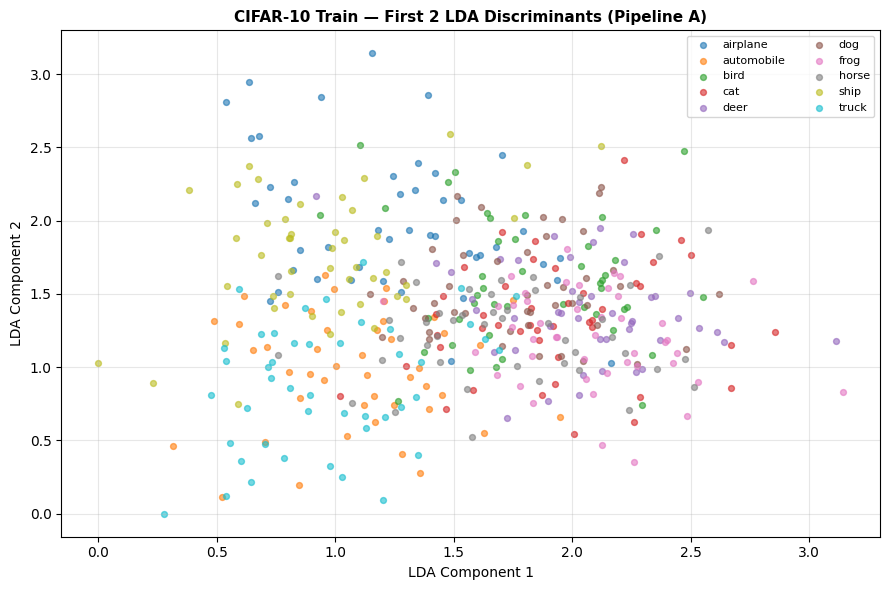

In [3]:
def _preprocess_pca_lda(X_train_raw, X_test_raw, y_train, lda_dims, pca_pre=PCA_PRENOISE):
    """Pipeline A: StandardScaler → PCA(pca_pre, whiten) → LDA(lda_dims) → MinMax[0,π].
    Fit on train only."""
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_raw)
    X_te = scaler.transform(X_test_raw)
    n_pca = min(pca_pre, X_tr.shape[0] - 1, X_tr.shape[1])
    pca = PCA(n_components=n_pca, whiten=True, random_state=SEED)
    X_tr = pca.fit_transform(X_tr)
    X_te = pca.transform(X_te)
    var_explained = pca.explained_variance_ratio_.sum()
    n_lda = min(lda_dims, len(np.unique(y_train)) - 1)
    lda = LDA(n_components=n_lda, solver='svd')
    X_tr = lda.fit_transform(X_tr, y_train)
    X_te = lda.transform(X_te)
    mm = MinMaxScaler(feature_range=(0, np.pi))
    X_tr = mm.fit_transform(X_tr)
    X_te = mm.transform(X_te)
    pipe = dict(scaler=scaler, pca=pca, lda=lda, minmax=mm,
                pca_var_explained=var_explained, n_lda=n_lda, n_pca=n_pca)
    return X_tr, X_te, pipe


def _preprocess_pca_only(X_train_raw, X_test_raw, n_pca_dims):
    """Pipeline B: StandardScaler → PCA(n_pca_dims, whiten) → MinMax[0,π].
    Used exclusively for PCE encoding (64-dim features on 8 qubits).
    Fit on train only — no leakage."""
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_raw)
    X_te = scaler.transform(X_test_raw)
    n_pca = min(n_pca_dims, X_tr.shape[0] - 1, X_tr.shape[1])
    pca = PCA(n_components=n_pca, whiten=True, random_state=SEED)
    X_tr = pca.fit_transform(X_tr)
    X_te = pca.transform(X_te)
    var_explained = pca.explained_variance_ratio_.sum()
    mm = MinMaxScaler(feature_range=(0, np.pi))
    X_tr = mm.fit_transform(X_tr)
    X_te = mm.transform(X_te)
    pipe_b = dict(scaler=scaler, pca=pca, minmax=mm,
                  pca_var_explained=var_explained, n_pca=n_pca)
    return X_tr, X_te, pipe_b


def _subsample_balanced(X, y, classes, n_per_class):
    idx_parts = []
    for c in classes:
        ci = np.where(y == c)[0]
        np.random.shuffle(ci)
        idx_parts.append(ci[:n_per_class])
    idx = np.concatenate(idx_parts)
    perm = np.random.RandomState(SEED).permutation(len(idx))
    return X[idx[perm]], y[idx[perm]]


def _relabel_consecutive(y, classes):
    lmap = {c: i for i, c in enumerate(sorted(set(classes)))}
    return np.array([lmap[yi] for yi in y])


def _digit_proxy_cifar10(n_per_class, lda_dims):
    print("  [CIFAR10_10cls] WARNING: using sklearn Digits as proxy")
    dig = load_digits()
    classes = list(range(10))
    X, y = _subsample_balanced(dig.data, dig.target, classes, n_per_class)
    y_mc = _relabel_consecutive(y, classes)
    Xtr_r, Xte_r, ytr, yte = train_test_split(
        X, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc)
    Xtr_p, Xte_p, pipe = _preprocess_pca_lda(Xtr_r, Xte_r, ytr, lda_dims,
                                               pca_pre=min(20, len(Xtr_r)-1))
    Xtr_pce, Xte_pce, pipe_b = _preprocess_pca_only(Xtr_r, Xte_r, min(64, X.shape[1]))
    return Xtr_p, Xte_p, ytr, yte, "PROXY", pipe, Xtr_pce, Xte_pce, pipe_b


def load_cifar10_multiclass(n_per_class=N_SAMPLES, lda_dims=DEFAULT_LDA,
                             pce_features=PCE_FEATURES):
    """Load CIFAR-10 and produce BOTH preprocessed datasets:
      - Pipeline A: PCA-50 → LDA-8  (Xtr, Xte)           for 17 encodings
      - Pipeline B: PCA-64 only     (Xtr_pce, Xte_pce)   for PCE encoding
    Returns: Xtr, Xte, ytr, yte, src, pipe, Xtr_pce, Xte_pce, pipe_b
    """
    classes = list(range(10))
    tag = "CIFAR10_10cls"
    raw_data = None

    # Tier 1: torchvision
    if raw_data is None:
        try:
            import torchvision, torchvision.transforms as T
            transform = T.ToTensor()
            tr_ds = torchvision.datasets.CIFAR10("/tmp/cifar10", train=True,  download=True, transform=transform)
            te_ds = torchvision.datasets.CIFAR10("/tmp/cifar10", train=False, download=True, transform=transform)
            X_tr = np.stack([img.permute(1,2,0).numpy() for img,_ in tr_ds])
            y_tr = np.array([lbl for _,lbl in tr_ds])
            X_te = np.stack([img.permute(1,2,0).numpy() for img,_ in te_ds])
            y_te = np.array([lbl for _,lbl in te_ds])
            X = np.concatenate([X_tr, X_te]); y = np.concatenate([y_tr, y_te])
            raw_data = (X.reshape(len(X), -1), y, "REAL-torchvision")
            print(f"  [{tag}] loaded via torchvision (RGB, 3072-d)")
        except Exception as e:
            print(f"  [{tag}] torchvision failed: {e}")

    # Tier 2: tensorflow
    if raw_data is None:
        try:
            from tensorflow.keras.datasets import cifar10
            (X_tr, y_tr), (X_te, y_te) = cifar10.load_data()
            y_tr = y_tr.flatten(); y_te = y_te.flatten()
            X = np.concatenate([X_tr, X_te]).astype(np.float32) / 255.0
            y = np.concatenate([y_tr, y_te])
            raw_data = (X.reshape(len(X), -1), y, "REAL-tensorflow")
            print(f"  [{tag}] loaded via tensorflow (RGB, 3072-d)")
        except Exception as e:
            print(f"  [{tag}] tensorflow failed: {e}")

    # Tier 3: fetch_openml
    if raw_data is None:
        try:
            from sklearn.datasets import fetch_openml
            d = fetch_openml("CIFAR_10", version=1, as_frame=False, parser="auto")
            raw_data = (d.data.astype(np.float32) / 255.0, d.target.astype(int), "REAL-openml")
            print(f"  [{tag}] loaded via fetch_openml (RGB, 3072-d)")
        except Exception as e:
            print(f"  [{tag}] fetch_openml failed: {e}")

    if raw_data is None:
        return _digit_proxy_cifar10(n_per_class, lda_dims)

    X_flat, y, src_label = raw_data
    X_s, y_s = _subsample_balanced(X_flat, y, classes, n_per_class)
    y_mc = _relabel_consecutive(y_s, classes)

    # Split BEFORE preprocessing (critical: prevent leakage)
    Xtr_r, Xte_r, ytr, yte = train_test_split(
        X_s, y_mc, test_size=0.25, random_state=SEED, stratify=y_mc)

    # Pipeline A: PCA → LDA (for 17 standard encodings)
    Xtr_p, Xte_p, pipe = _preprocess_pca_lda(Xtr_r, Xte_r, ytr, lda_dims)

    # Pipeline B: PCA-64 only (for PCE — needs 64 features on 8 qubits)
    Xtr_pce, Xte_pce, pipe_b = _preprocess_pca_only(Xtr_r, Xte_r, pce_features)

    print(f"  [{tag}] {src_label}")
    print(f"    Pipeline A (LDA): PCA-{pipe['n_pca']} (var={pipe['pca_var_explained']:.1%})"
          f" → LDA-{pipe['n_lda']} → shape {Xtr_p.shape}")
    print(f"    Pipeline B (PCE): PCA-{pipe_b['n_pca']} (var={pipe_b['pca_var_explained']:.1%})"
          f" → shape {Xtr_pce.shape}")

    return Xtr_p, Xte_p, ytr, yte, src_label, pipe, Xtr_pce, Xte_pce, pipe_b


print(f"Loading CIFAR-10 (N_SAMPLES={N_SAMPLES}/class, 10 classes, RGB) ...")
t0 = time.time()

Xtr, Xte, ytr, yte, src, pipe, Xtr_pce, Xte_pce, pipe_b = load_cifar10_multiclass()

data        = {"CIFAR10_10cls": (Xtr, Xte, ytr, yte)}
data_pce    = {"CIFAR10_10cls": (Xtr_pce, Xte_pce, ytr, yte)}
data_source = {"CIFAR10_10cls": src}
data_pipe   = {"CIFAR10_10cls": pipe}
data_pipe_b = {"CIFAR10_10cls": pipe_b}

print(f"\nDone in {time.time()-t0:.1f}s")
print(f"  LDA data  (Pipeline A): train {Xtr.shape},     test {Xte.shape}")
print(f"  PCE data  (Pipeline B): train {Xtr_pce.shape}, test {Xte_pce.shape}")

# LDA scatter plot
fig, ax = plt.subplots(figsize=(9, 6))
palette_lda = plt.cm.tab10(np.linspace(0, 1, 10))
for cls_i in range(10):
    mask = ytr == cls_i
    ax.scatter(Xtr[mask, 0], Xtr[mask, 1],
               label=CIFAR10_CLASS_NAMES[cls_i], alpha=0.6, s=18,
               color=palette_lda[cls_i])
ax.set_xlabel("LDA Component 1"); ax.set_ylabel("LDA Component 2")
ax.set_title("CIFAR-10 Train — First 2 LDA Discriminants (Pipeline A)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_scatter_cifar10.png", dpi=140, bbox_inches="tight")
plt.show()


## 2 · Full Pipeline Diagram

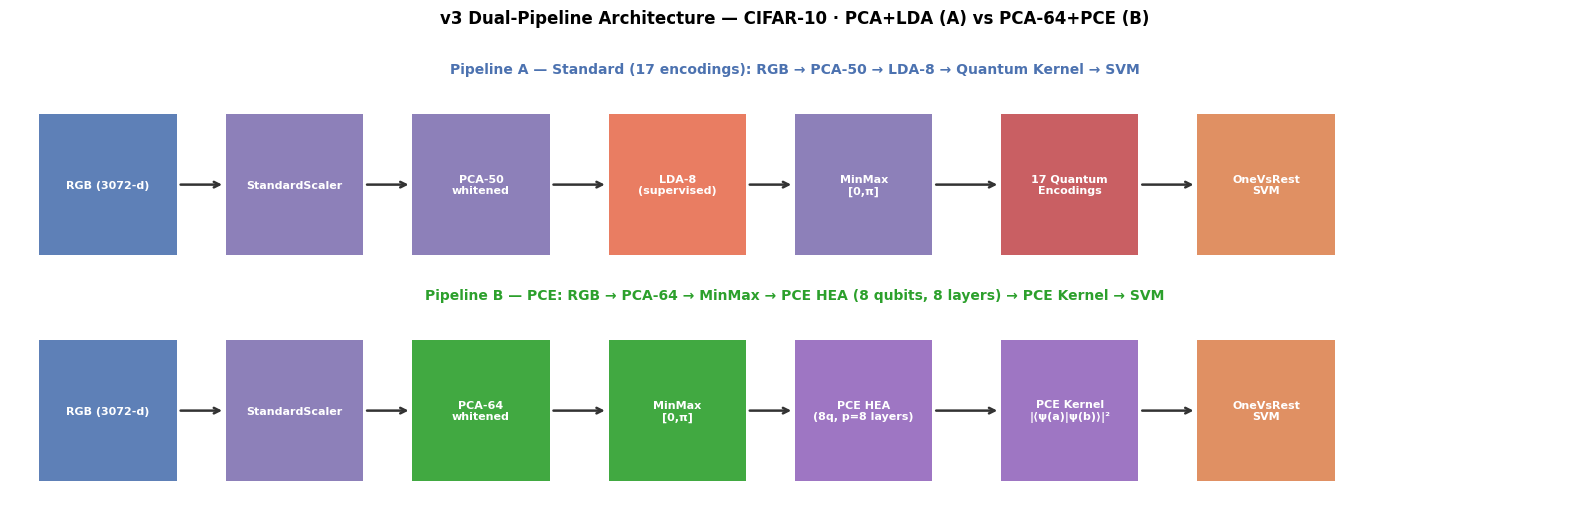

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce\pipeline_diagram_pce.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 5))

def _draw_pipe(ax, stages, colors, y_text, title, title_color):
    ax.set_xlim(0, 16); ax.set_ylim(0, 2.2); ax.axis('off')
    for i, (label, x) in enumerate(stages):
        ax.add_patch(plt.Rectangle((x-0.7, 0.2), 1.4, 1.6,
                                    color=colors[i], alpha=0.9, zorder=2, linewidth=0))
        ax.text(x, 1.0, label, ha='center', va='center', fontsize=8,
                color='white', fontweight='bold', zorder=3)
        if i < len(stages)-1:
            ax.annotate('', xy=(stages[i+1][1]-0.71, 1.0), xytext=(x+0.71, 1.0),
                        arrowprops=dict(arrowstyle='->', color='#333', lw=1.8))
    ax.set_title(title, fontsize=10, fontweight='bold', color=title_color, pad=4)

pipeA = [
    ('RGB (3072-d)', 1.0), ('StandardScaler', 2.9), ('PCA-50\nwhitened', 4.8),
    ('LDA-8\n(supervised)', 6.8), ('MinMax\n[0,π]', 8.7),
    ('17 Quantum\nEncodings', 10.8), ('OneVsRest\nSVM', 12.8),
]
colA = ['#4C72B0','#8172B2','#8172B2','#E76F51','#8172B2','#C44E52','#DD8452']

pipeB = [
    ('RGB (3072-d)', 1.0), ('StandardScaler', 2.9), ('PCA-64\nwhitened', 4.8),
    ('MinMax\n[0,π]', 6.8), ('PCE HEA\n(8q, p=8 layers)', 8.7),
    ('PCE Kernel\n|⟨ψ(a)|ψ(b)⟩|²', 10.8), ('OneVsRest\nSVM', 12.8),
]
colB = ['#4C72B0','#8172B2','#2ca02c','#2ca02c','#9467bd','#9467bd','#DD8452']

_draw_pipe(axes[0], pipeA, colA, 1.0,
           'Pipeline A — Standard (17 encodings): RGB → PCA-50 → LDA-8 → Quantum Kernel → SVM',
           '#4C72B0')
_draw_pipe(axes[1], pipeB, colB, 1.0,
           'Pipeline B — PCE: RGB → PCA-64 → MinMax → PCE HEA (8 qubits, 8 layers) → PCE Kernel → SVM',
           '#2ca02c')

plt.suptitle('v3 Dual-Pipeline Architecture — CIFAR-10 · PCA+LDA (A) vs PCA-64+PCE (B)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pipeline_diagram_pce.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUTPUT_DIR / 'pipeline_diagram_pce.png')


## 3 · Quantum Encoding Circuits (All 17 — Corrected)

### Correction notes
- **IQP** (old): only nearest-neighbour `IsingZZ` in 1 layer → **new**: ALL pairs `RZZ(xᵢxⱼ)` via CNOT·RZ·CNOT, applied in **2 full layers** (Havlíček et al.)
- **QHE** (old): simple `RY(x) + RZ(φ) + CRZ(...)` → **new**: `H → PhaseShift(2πx/λ) → adjoint(QFT)` (correct Quantum Helix Encoding)
- **DenseAngle** (old): only `RY(x₂ᵢ) + RZ(x₂ᵢ₊₁)` → **new**: `H → RZ(xᵢ²) → CNOT·RZ(xᵢxⱼ)·CNOT` cross-terms
- **FRQI** (old): wrong controlled-RY wire selection → **new**: circular `CRY(2θ, [i,(i+1)%n_qubits])` on uniform superposition


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 1 — ANGLE / ROTATION ENCODINGS
# ═══════════════════════════════════════════════════════════════════════════

def rotational_encoding(x, n_qubits):
    """Standard rotation encoding: RY(xⱼ) on each qubit j.
    Reference: basic angle embedding, used as baseline in all papers."""    
    for i in range(n_qubits):
        qml.RY(x[i % len(x)], wires=i)


def simple_angle_encoding(x, n_qubits):
    """Simple angle encoding: RX(xⱼ) on each qubit j.
    Reference: Zang et al. arXiv:2505.14295 Encoding 1 (Eq. 2-3)"""    
    for i in range(n_qubits):
        qml.RX(x[i % len(x)], wires=i)


def pi4_angle_encoding(x, n_qubits):
    """pi/4 angle encoding: H then RY(2xⱼ) per qubit.
    Net state: cos(xⱼ)|0> + sin(xⱼ)|1>  (Eq. 4-6 of Zang et al.)
    Reference: Zang et al. arXiv:2505.14295 Encoding 2"""    
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RY(2 * x[i % len(x)], wires=i)


def entangled_angle_encoding(x, n_qubits):
    """Entangled angle encoding: H → RY(xⱼ) → CNOT chain.
    Reference: Zang et al. arXiv:2505.14295 Encoding 3 (Fig 1.2)"""    
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for i in range(n_qubits):
        qml.RY(x[i % len(x)], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 2 — BASIS / AMPLITUDE / DENSE ENCODINGS
# ═══════════════════════════════════════════════════════════════════════════

def basis_encoding(x, n_qubits):
    """Basis encoding: flip qubit i if feature > pi/2.
    Reference: standard computational basis encoding."""    
    for i in range(n_qubits):
        if x[i % len(x)] > np.pi / 2:
            qml.PauliX(wires=i)


def amplitude_encoding(x, n_qubits):
    """Amplitude encoding using ceil(log2(n_features)) qubits.
    Note: effective qubit count is fixed by feature dimensionality.
    Reference: Mottonen et al.; Zang et al. arXiv:2505.14295 Section 1.2"""    
    n_amp_qubits = max(1, int(np.ceil(np.log2(len(x)))))
    n_amps = 2 ** n_amp_qubits
    padded = np.zeros(n_amps)
    padded[:len(x)] = x
    norm = np.linalg.norm(padded)
    padded = padded / norm if norm > 1e-9 else np.eye(n_amps)[0]
    qml.AmplitudeEmbedding(padded, wires=range(n_amp_qubits), normalize=False)


def dense_angle_encoding(x, n_qubits):
    """Dense angle encoding (CORRECTED from v9).
    Old v9: only RY(x_{2i}) + RZ(x_{2i+1}) — missed cross-feature entanglement.
    Corrected: H → RZ(xᵢ²) → CNOT·RZ(xᵢxⱼ)·CNOT cross-terms (BTP reference).
    Reference: BTP benchmark notebook (DenseAngleEncoder class)"""    
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Single-qubit quadratic phase
    for i in range(n_qubits):
        xi = x[i % len(x)]
        qml.RZ(xi * xi, wires=i)
    # Cross-feature entangling terms (up to 2-hop neighbourhood)
    for i in range(n_qubits - 1):
        for j in range(i + 1, min(i + 3, n_qubits)):
            xi = x[i % len(x)]
            xj = x[j % len(x)]
            qml.CNOT(wires=[i, j])
            qml.RZ(xi * xj, wires=j)
            qml.CNOT(wires=[i, j])


def shot_based_encoding(x, n_qubits):
    """Shot-based / probability-weighted encoding.
    Converts features to probabilities via softmax, then encodes as
    RY(2·arcsin(sqrt(pᵢ))) with CRY entanglement between adjacent qubits.
    Reference: BTP benchmark notebook (ShotBasedEncoder class)"""    
    p = x / (x.sum() + 1e-10)
    for i in range(n_qubits):
        qml.RY(2 * np.arcsin(np.sqrt(np.clip(p[i % len(p)], 0, 1))), wires=i)
    for i in range(n_qubits - 1):
        pi = p[i % len(p)]
        pip1 = p[(i + 1) % len(p)]
        qml.CRY(float(pi * pip1) * np.pi, wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 3 — IMAGE ENCODINGS (FRQI / NEQR)
# ═══════════════════════════════════════════════════════════════════════════

def frqi_encoding(x, n_qubits):
    """FRQI encoding (CORRECTED from v9).
    FRQI principle: colour info (pixel intensity) encoded as controlled-RY
    rotation angle, conditioned on positional superposition.
    Old v9: used wrong ctrl_wires logic (bit-based indexing) — wrong for ML context.
    Corrected: H on all → CRY(2θᵢ, [i, (i+1)%n]) circular structure.
    Reference: FRQI/NEQR paper, frqi_encoding() in FRQI_NEQR notebook (Sec 4.1)"""    # Step 1: Hadamard to create uniform superposition (position register)
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Step 2: Controlled-RY — each qubit i controls rotation on qubit (i+1)%n
    # theta_i = feature_i (already in [0, pi] after preprocessing)
    for i in range(n_qubits):
        theta = x[i % len(x)]
        qml.CRY(2 * theta, wires=[i, (i + 1) % n_qubits])


def neqr_encoding(x, n_qubits):
    """NEQR encoding (NEW — from FRQI/NEQR paper, fixed version).
    NEQR stores pixel intensity in the computational basis (not rotation angles).
    Steps:
      1. H on all qubits → position superposition
      2. RZ(2π·normalised_pixel_value) — Z-basis phase encoding of 8-bit grey level
      3. PhaseShift + CNOT — couple colour (phase) to position (wire index)
      4. CNOT ladder — position-colour entanglement
    Reference: FRQI/NEQR paper, neqr_encoding() (fixed) in FRQI_NEQR notebook (Sec 4.1)"""    # Step 1: position superposition
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Step 2: RZ basis-state phase (normalised pixel → [0, 2π])
    for i in range(n_qubits):
        pixel_val_norm = x[i % len(x)] / np.pi   # feature in [0,π] → normalise to [0,1]
        qml.RZ(2 * np.pi * pixel_val_norm, wires=i)
    # Step 3: Controlled-phase coupling colour to position
    for i in range(n_qubits):
        qml.PhaseShift(x[i % len(x)], wires=i)
        qml.CNOT(wires=[i, (i + 1) % n_qubits])
    # Step 4: CNOT entanglement ladder
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 4 — ENTANGLED KERNEL ENCODINGS (IQP / QHE)
# ═══════════════════════════════════════════════════════════════════════════

def iqp_encoding(x, n_qubits):
    """IQP encoding (CORRECTED from v9).
    Old v9: only nearest-neighbour IsingZZ in 1 layer — incomplete IQP structure.
    Corrected: TWO full IQP layers, each = H → RZ(xⱼ) → RZZ(xⱼxₖ) ALL pairs.
    RZZ decomposition: CNOT · RZ(θ) · CNOT  (Eq. 14-15 of Zang et al.)
    Reference: Havlíček et al. Nature 2019; Zang et al. arXiv:2505.14295 Encoding 5"""
    def _one_iqp_layer(x, n_qubits):
        # H on all qubits
        for j in range(n_qubits):
            qml.Hadamard(wires=j)
        # Single-qubit RZ diagonal gates
        for j in range(n_qubits):
            qml.RZ(x[j % len(x)], wires=j)
        # All-pairs RZZ cross-feature terms (CNOT·RZ·CNOT decomposition)
        for j in range(n_qubits):
            for k in range(j + 1, n_qubits):
                theta_jk = x[j % len(x)] * x[k % len(x)]
                qml.CNOT(wires=[j, k])
                qml.RZ(theta_jk, wires=k)
                qml.CNOT(wires=[j, k])

    # Two full IQP layers (|ψ⟩ = Uz H⊗n Uz H⊗n |0⟩⊗n)
    _one_iqp_layer(x, n_qubits)
    _one_iqp_layer(x, n_qubits)


def qhe_encoding(x, n_qubits):
    """QHE — Quantum Helix Encoding (CORRECTED from v9).
    Old v9: RY(x) + RZ(λ·x·(i+1)·π/n) + CRZ(...) — ad-hoc approximation, not QHE.
    Corrected: H → PhaseShift(2π·xⱼ/λ) → adjoint(QFT)
    This is the exact QHE-base circuit from the QHE v6 paper (qhe_base circuit).
    The IQFT after PhaseShift creates the helical interference pattern in Hilbert space.
    Reference: QHE benchmark v6 notebook (qhe_base circuit)"""    
    lam = LAMBDA_QHE   # 2π
    # Step 1: Hadamard superposition
    for j in range(n_qubits):
        qml.Hadamard(wires=j)
    # Step 2: PhaseShift encoding (linear phase, 2π·x/λ per qubit)
    for j in range(n_qubits):
        phi = 2 * np.pi * float(x[j % len(x)]) / lam
        if abs(phi) > 1e-9:
            qml.PhaseShift(phi, wires=j)
    # Step 3: adjoint QFT — creates helical pattern
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 5 — HAMILTONIAN ENCODING (NEW)
# ═══════════════════════════════════════════════════════════════════════════

def hamiltonian_encoding(x, n_qubits, trotter_steps=2, t=1.0):
    """Hamiltonian encoding via Trotterised time evolution (NEW).
    H(x) = Σᵢ xᵢZᵢ + Σᵢ<ⱼ xᵢxⱼXᵢXⱼ
    |ψ(x)⟩ = exp(-i t H(x)) |0...0⟩  (approx. via 1st-order Trotter)
    Each Trotter step:
      exp(-i dt xᵢ Zᵢ) = RZ(2 dt xᵢ) on qubit i
      exp(-i dt xᵢxⱼ XᵢXⱼ) = CNOT·RX(2 dt xᵢxⱼ)·CNOT on (i,j)
    Reference: arXiv:2504.10542, hamiltonian_encoding_benchmark notebook"""    
    dt = t / trotter_steps
    # Initial superposition: |0...0⟩ → |+...+⟩
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    # Trotterised steps
    for _ in range(trotter_steps):
        # Local Z terms: exp(-i dt xᵢ Zᵢ) = RZ(2 dt xᵢ)
        for i in range(n_qubits):
            qml.RZ(2.0 * dt * float(x[i % len(x)]), wires=i)
        # Pairwise XX terms: exp(-i dt xᵢxⱼ XᵢXⱼ) via CNOT·RX·CNOT
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                coupling = float(x[i % len(x)]) * float(x[j % len(x)])
                angle = 2.0 * dt * coupling
                qml.CNOT(wires=[i, j])
                qml.RX(angle, wires=j)
                qml.CNOT(wires=[i, j])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 6 — GRAPH ENCODING (NEW)
# ═══════════════════════════════════════════════════════════════════════════

def _graph_laplacian(x, k=3):
    """Normalised graph Laplacian from k-nearest-neighbour Gaussian kernel."""    
    n = len(x)
    d = np.abs(x[:, None] - x[None, :])
    A = np.zeros((n, n))
    for i in range(n):
        neighbors = np.argsort(d[i])[:k + 1]
        for j in neighbors:
            if j != i:
                A[i, j] = A[j, i] = np.exp(-d[i, j])
    D = np.diag(A.sum(axis=1))
    Di = np.diag(1.0 / np.sqrt(np.maximum(np.diag(D), 1e-10)))
    return np.eye(n) - Di @ A @ Di


def graph_encoding(x, n_qubits, k=3):
    """Graph encoding using graph Laplacian eigendecomposition (NEW).
    1. H on all qubits
    2. RZ(eigenvalue · π) + RY(eigenvector[0] · π) per qubit
    3. CZ entanglement between adjacent qubits
    Reference: BTP benchmark notebook (GraphEncoder class)
    Fix: k capped at n_qubits-1 so the kNN graph is never degenerate.
    At n_qubits=2, k=3 caused a 2×2 Laplacian with constant eigenvectors
    → kernel K(x,x')=1 for all pairs → SVM predicted majority class → chance accuracy."""
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    x_slice = x[:n_qubits]
    if len(x_slice) < n_qubits:
        x_slice = np.pad(x_slice, (0, n_qubits - len(x_slice)))
    k_eff = max(1, min(k, n_qubits - 1))   # FIX: cap k so graph is never fully connected
    ev, evec = np.linalg.eigh(_graph_laplacian(x_slice, k_eff))
    for i in range(n_qubits):
        qml.RZ(float(ev[i]) * np.pi, wires=i)
        qml.RY(float(evec[i, 0]) * np.pi, wires=i)
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i + 1])


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 7 — AQHE VARIANTS (NEW — from QHE v6 paper)
# ═══════════════════════════════════════════════════════════════════════════

def _log_helix_phase(x_j, lam=LAMBDA_QHE, beta=LOG_BETA):
    """Log1p-compressed phase: maps [0, 2π] → [0, 2π] monotonically.
    More phase resolution at small feature values (where CIFAR PCA mass concentrates).
    beta=0 → linear (QHE-base); beta>>1 → fully logarithmic."""    
    return 2 * np.pi * np.log1p(beta * x_j / (2 * np.pi)) / np.log1p(beta)


def aqhe_loghelix_encoding(x, n_qubits):
    """AQHE-LogHelix: H → LogPhaseShift(log_helix_phase) → adjoint(QFT).
    Addresses aliasing: log compression concentrates kernel resolution
    where feature mass is, giving more phase resolution at small values.
    Reference: QHE v6 paper, aqhe_loghelix circuit"""    
    for j in range(n_qubits):
        qml.Hadamard(wires=j)
    for j in range(n_qubits):
        phi = _log_helix_phase(float(x[j % len(x)]))
        if abs(phi) > 1e-9:
            qml.PhaseShift(phi, wires=j)
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


def aqhe_fibspiral_encoding(x, n_qubits):
    """AQHE-FibSpiral: Fibonacci golden-angle spiral on Bloch sphere.
    Encodes feature xⱼ as a point on the Bloch sphere:
      θⱼ = arccos(1 - 2·xⱼ/2π)   (polar, latitude)
      φⱼ = golden_angle·j + xⱼ/λ  (azimuthal, golden spiral)
    Non-stationary kernel: K(x,x') depends on x and x' independently.
    Fibonacci lattice: maximum angular separation between qubit manifolds.
    Reference: QHE v6 paper, aqhe_fibspiral circuit"""    
    for j in range(n_qubits):
        x_norm  = np.clip(float(x[j % len(x)]) / (2 * np.pi), 0.0, 1.0)
        theta_j = float(np.arccos(1.0 - 2.0 * x_norm))   # polar angle [0, π]
        phi_j   = float(GOLDEN_ANGLE * j + float(x[j % len(x)]) / LAMBDA_QHE)
        qml.RY(theta_j, wires=j)
        phi_mod = phi_j % (2 * np.pi)
        if abs(phi_mod) > 1e-9:
            qml.PhaseShift(phi_mod, wires=j)
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


def aqhe_dualenc_encoding(x, n_qubits):
    """AQHE-DualEnc: Dual amplitude-phase encoding (2 DoF per qubit).
    amp_j  = 2·arctan(xⱼ/π)          [arctan soft saturation → Bloch amplitude]
    phi_j  = 2π·log1p(xⱼ)/log1p(2π)  [log-compressed Bloch phase]
    Non-stationary: RY amplitude makes K(x,x') depend on x,x' independently.
    arctan robustness: handles heavy-tailed PCA distributions without clipping.
    Reference: QHE v6 paper, aqhe_dualenc circuit"""    
    for j in range(n_qubits):
        xj = float(x[j % len(x)])
        amp_j = float(2.0 * np.arctan(xj / np.pi))              # [0, π)
        phi_j = float(2 * np.pi * np.log1p(xj) / np.log1p(2 * np.pi))  # log-compressed
        qml.RY(amp_j, wires=j)
        if abs(phi_j) > 1e-9:
            qml.PhaseShift(phi_j, wires=j)
    qml.adjoint(qml.QFT)(wires=range(n_qubits))


# ═══════════════════════════════════════════════════════════════════════════
#  ENCODING REGISTRY
# ═══════════════════════════════════════════════════════════════════════════


# ═══════════════════════════════════════════════════════════════════════════
#  GROUP 8 — PCE (PAULI CORRELATION ENCODING)  [NEW — v3]
# ═══════════════════════════════════════════════════════════════════════════
#
# Adaptation of Soloviev & Krompiec (2025) / Sciorilli et al. (2025) PCE.
#
# Original PCE: HEA circuit with TRAINABLE θ for portfolio MAX-CUT.
# Our adaptation: HEA circuit with DATA-DRIVEN angles for quantum kernel.
#
# Circuit structure (Hardware Efficient Ansatz):
#   For each of p = floor(m/n) layers:
#     Step 1 — Data encoding:  RY(x_{l*n + i}) on qubit i
#               (features indexed modulo m to handle all 64 inputs)
#     Step 2 — Entanglement:   CZ on pairs (0,1), (1,2), ..., (n-2,n-1)
#               (linear entangling structure as in the paper's Fig. 2)
#   Final layer: RY(x_{p*n + i}) on each qubit (no CZ after last layer)
#
# Kernel computation:
#   K(x_a, x_b) = |<ψ(x_a)|ψ(x_b)>|²
#   where |ψ(x)> = HEA(x)|0...0>
#   Computed as squared overlap of statevectors via qml.state()
#
# Pauli correlation decoding (for reference — used in portfolio mode only):
#   x_i = sgn(<Π_i>)  where Π_i is a k-body Pauli string on n qubits
#   m_max = C(n,k) × 3^k  (e.g. n=8,k=2 → 252 ≥ 64  ✓)
#   In kernel mode this is not used; the kernel is the state overlap.
#
def pce_hea_encoding(x, n_qubits,
                     p_layers=None,
                     k_order=None):
    """PCE Hardware-Efficient Ansatz as a data-encoding circuit.

    Each feature x_i ∈ [0,π] (after MinMax scaling) is loaded as the
    rotation angle of an RY gate in the HEA. Linear CZ entanglement
    between consecutive qubits creates multi-qubit correlations that
    allow the kernel to capture cross-feature dependencies.

    Parameters
    ----------
    x        : feature vector of length PCE_FEATURES (default 64)
    n_qubits : number of qubits (PCE_N_QUBITS, default 8)
    p_layers : HEA layers (default PCE_P_LAYERS = floor(m/n) = 8)
    k_order  : PCE order (informational, default 2); governs m_max capacity.
    """
    import pennylane as qml
    if p_layers is None:
        p_layers = PCE_P_LAYERS   # floor(64/8) = 8
    m = len(x)

    for layer in range(p_layers):
        # ── Data encoding: RY(x_j) on each qubit j ──────────────────────
        for i in range(n_qubits):
            feat_idx = (layer * n_qubits + i) % m
            qml.RY(x[feat_idx], wires=i)
        # ── Linear CZ entanglement ────────────────────────────────────────
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i + 1])

    # Final RY layer (no CZ — matches paper Fig. 2 boundary).
    # FIX: when m is an exact multiple of n_qubits (our default: p_layers=8,
    # n_qubits=8, m=64), (p_layers*n_qubits + i) % m == i, so this layer was
    # silently re-encoding features 0..7 that layer 0 already applied —
    # adding 8 extra RY gates (and extra circuit depth) with zero new
    # information. Only emit the boundary layer when there is a genuine
    # remainder of un-encoded features left over.
    remainder = m - (p_layers * n_qubits) % m
    if (p_layers * n_qubits) % m != 0:
        for i in range(n_qubits):
            feat_idx = (p_layers * n_qubits + i) % m
            qml.RY(x[feat_idx], wires=i)


def pce_encoding(x, n_qubits):
    """Thin wrapper so PCE fits the standard encoding signature (x, n_qubits).

    NOTE: When called from build_kernel_matrix for the PCE encoding,
    the caller must pass data from data_pce (64-dim) not data (8-dim LDA).
    The benchmark loop handles this via the PCE_DATA_KEY mechanism.
    """
    pce_hea_encoding(x, n_qubits)

ENCODING_FNS = {
    # Group 1: Angle/Rotation
    "Rotational"     : rotational_encoding,
    "SimpleAngle"    : simple_angle_encoding,
    "Pi4Angle"       : pi4_angle_encoding,
    "EntangledAngle" : entangled_angle_encoding,
    # Group 2: Basis/Amplitude/Dense
    "Basis"          : basis_encoding,
    "Amplitude"      : amplitude_encoding,
    "DenseAngle"     : dense_angle_encoding,
    "ShotBased"      : shot_based_encoding,
    # Group 3: Image encodings
    "FRQI"           : frqi_encoding,
    "NEQR"           : neqr_encoding,
    # Group 4: Entangled kernel
    "IQP"            : iqp_encoding,
    "QHE"            : qhe_encoding,
    # Group 5: Hamiltonian
    "Hamiltonian"    : hamiltonian_encoding,
    # Group 6: Graph
    "GraphEncoding"  : graph_encoding,
    # Group 7: AQHE variants
    "AQHE_LogHelix"  : aqhe_loghelix_encoding,
    "AQHE_FibSpiral" : aqhe_fibspiral_encoding,
    "AQHE_DualEnc"   : aqhe_dualenc_encoding,
    # Group 8: PCE (new — v3, 64-dim PCA input)
    "PCE"            : pce_encoding,
}

# Map encodings to their data source
# "lda" → data (LDA-8 features, 8 qubits)
# "pce" → data_pce (PCA-64 features, 8 qubits)
ENCODING_DATA_SOURCE = {enc: "lda" for enc in ENCODING_FNS}
ENCODING_DATA_SOURCE["PCE"] = "pce"

print("Registered encodings:", list(ENCODING_FNS.keys()))
print(f"Total: {len(ENCODING_FNS)}")
print(f"PCE uses data_pce (PCA-64): {ENCODING_DATA_SOURCE['PCE']}")


Registered encodings: ['Rotational', 'SimpleAngle', 'Pi4Angle', 'EntangledAngle', 'Basis', 'Amplitude', 'DenseAngle', 'ShotBased', 'FRQI', 'NEQR', 'IQP', 'QHE', 'Hamiltonian', 'GraphEncoding', 'AQHE_LogHelix', 'AQHE_FibSpiral', 'AQHE_DualEnc', 'PCE']
Total: 18
PCE uses data_pce (PCA-64): pce


### 3.1 · Circuit Drawings for Each Encoding

### 3.2 · PCE Circuit Architecture & Capacity Analysis (new in v3)

**PCE capacity formula:** $m_{max}(n, k) = \\binom{n}{k} \\times 3^k$

| n (qubits) | k=1 | k=2 | k=3 |
|---|---|---|---|
| 6 | 18 | 135 | 540 |
| **8** | **24** | **252 ✓** | **1512** |
| 10 | 30 | 405 | 3240 |

With n=8, k=2: **m_max = 252 ≥ 64** ✓ — encodes all 64 PCA features on 8 qubits.

**HEA structure** (paper Fig. 2, linear CZ entangling):
- p = floor(64/8) = **8 layers**, each: RY(x_feature) per qubit → CZ chain
- Plus one final RY layer → total (8+1)×8 = 72 RY + 8×7 = 56 CZ = **128 gates**
- Compare QAOA at m=250: 42,000+ gates

**In kernel mode** (our adaptation): K(x_a, x_b) = |⟨ψ(x_a)|ψ(x_b)⟩|²
The statevector captures all C(8,2)=28 pairwise and higher-order correlations
among 64 input features — far richer than a single-layer angle encoding.


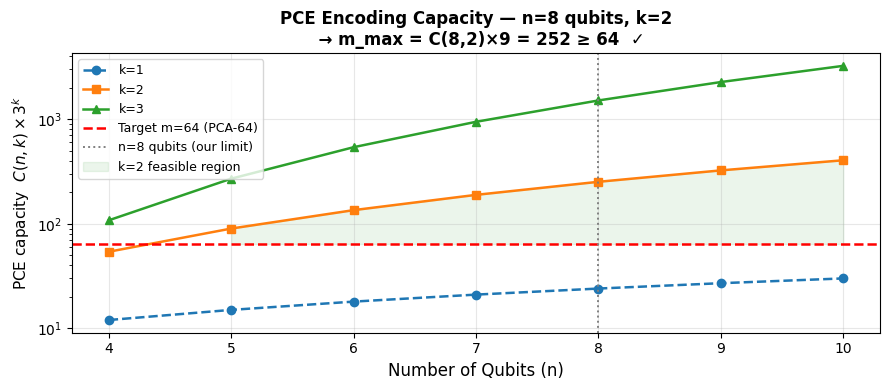

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce\pce_capacity_chart.png

PCE HEA example circuit (n=4 qubits, m=8 features, p=2 layers):
0: ──RY(0.10)─╭●──RY(1.78)───────────╭●──────────────┤  State
1: ──RY(0.52)─╰Z─╭●─────────RY(2.20)─╰Z────────╭●────┤  State
2: ──RY(0.94)────╰Z────────╭●─────────RY(2.62)─╰Z─╭●─┤  State
3: ──RY(1.36)──────────────╰Z─────────RY(3.04)────╰Z─┤  State

Full benchmark PCE config (n=8, m=64):
  HEA layers   : p = floor(64/8) = 8
  RY gates     : (8+1) × 8 = 72
  CZ gates     : 8 × 7 = 56
  Total gates  : 128
  Statevector  : 2^8 = 256 amplitudes
  Alpha (α)    : 8^floor(2/2) = 8


In [6]:
# PCE Capacity Chart + Example Circuit
from math import comb as _comb

# ── Capacity chart ────────────────────────────────────────────────────────────
ns = list(range(4, 11))
fig, ax = plt.subplots(figsize=(9, 4))
for k, style in [(1,'o--'), (2,'s-'), (3,'^-')]:
    m_maxs = [_comb(n, k) * (3**k) for n in ns]
    ax.plot(ns, m_maxs, style, label=f'k={k}', linewidth=1.8, markersize=6)
ax.axhline(PCE_FEATURES, color='red', linestyle='--', linewidth=1.8,
           label=f'Target m={PCE_FEATURES} (PCA-64)')
ax.axvline(PCE_N_QUBITS, color='gray', linestyle=':', linewidth=1.4,
           label=f'n={PCE_N_QUBITS} qubits (our limit)')
ax.fill_between(ns,
                PCE_FEATURES,
                [_comb(n, 2) * 9 for n in ns],
                where=[_comb(n,2)*9 >= PCE_FEATURES for n in ns],
                alpha=0.08, color='green', label='k=2 feasible region')
ax.set_xlabel('Number of Qubits (n)', fontsize=12)
ax.set_ylabel('PCE capacity  $C(n,k) \\times 3^k$', fontsize=11)
ax.set_title(f'PCE Encoding Capacity — n={PCE_N_QUBITS} qubits, k={PCE_K_ORDER}\n'
             f'  → m_max = C({PCE_N_QUBITS},{PCE_K_ORDER})×{3**PCE_K_ORDER}'
             f' = {_comb(PCE_N_QUBITS,PCE_K_ORDER)*(3**PCE_K_ORDER)} ≥ {PCE_FEATURES}  ✓',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_yscale('log')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pce_capacity_chart.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved:', OUTPUT_DIR / 'pce_capacity_chart.png')

# ── Example PCE circuit (4 qubits, 8 features for readability) ───────────────
print('\nPCE HEA example circuit (n=4 qubits, m=8 features, p=2 layers):')
n_demo = 4; m_demo = 8; p_demo = m_demo // n_demo
dev_demo = get_device(n_demo)
@qml.qnode(dev_demo)
def _pce_demo(x):
    pce_hea_encoding(x, n_demo, p_layers=p_demo)
    return qml.state()
x_demo = np.linspace(0.1, np.pi - 0.1, m_demo)
print(qml.draw(_pce_demo)(x_demo))

print(f'\nFull benchmark PCE config (n={PCE_N_QUBITS}, m={PCE_FEATURES}):')
print(f'  HEA layers   : p = floor({PCE_FEATURES}/{PCE_N_QUBITS}) = {PCE_P_LAYERS}')
print(f'  RY gates     : ({PCE_P_LAYERS}+1) × {PCE_N_QUBITS} = {(PCE_P_LAYERS+1)*PCE_N_QUBITS}')
print(f'  CZ gates     : {PCE_P_LAYERS} × {PCE_N_QUBITS-1} = {PCE_P_LAYERS*(PCE_N_QUBITS-1)}')
print(f'  Total gates  : {(PCE_P_LAYERS+1)*PCE_N_QUBITS + PCE_P_LAYERS*(PCE_N_QUBITS-1)}')
print(f'  Statevector  : 2^{PCE_N_QUBITS} = {2**PCE_N_QUBITS} amplitudes')
print(f'  Alpha (α)    : {PCE_N_QUBITS}^floor({PCE_K_ORDER}/2) = {PCE_ALPHA}')



=== Rotational ===


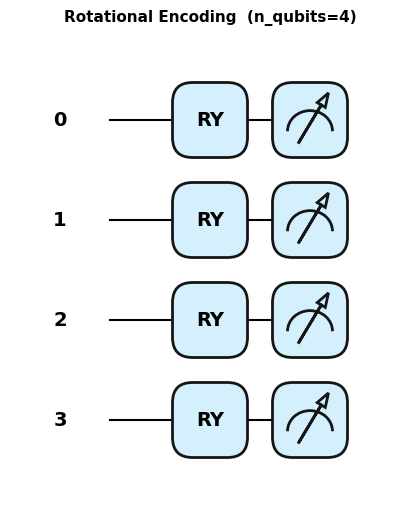

  Circuit depth for Rotational: 1

=== SimpleAngle ===


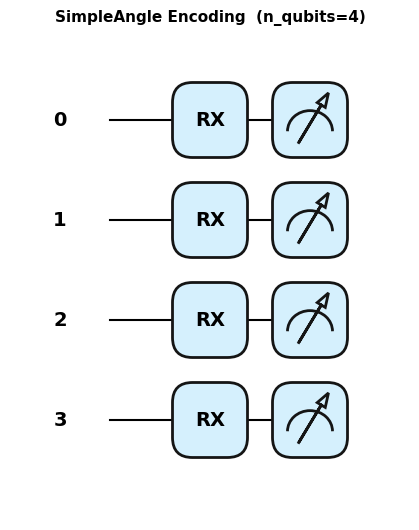

  Circuit depth for SimpleAngle: 1

=== Pi4Angle ===


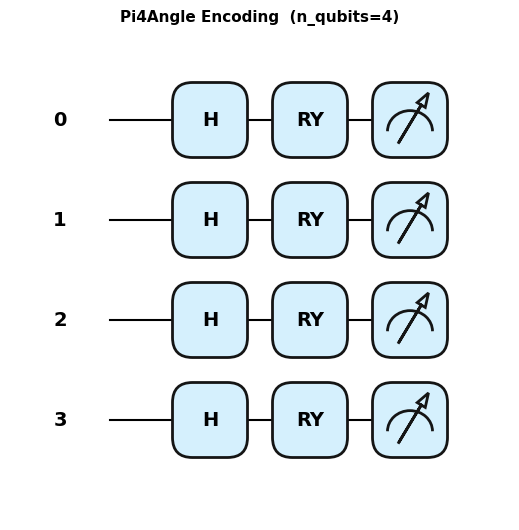

  Circuit depth for Pi4Angle: 2

=== EntangledAngle ===


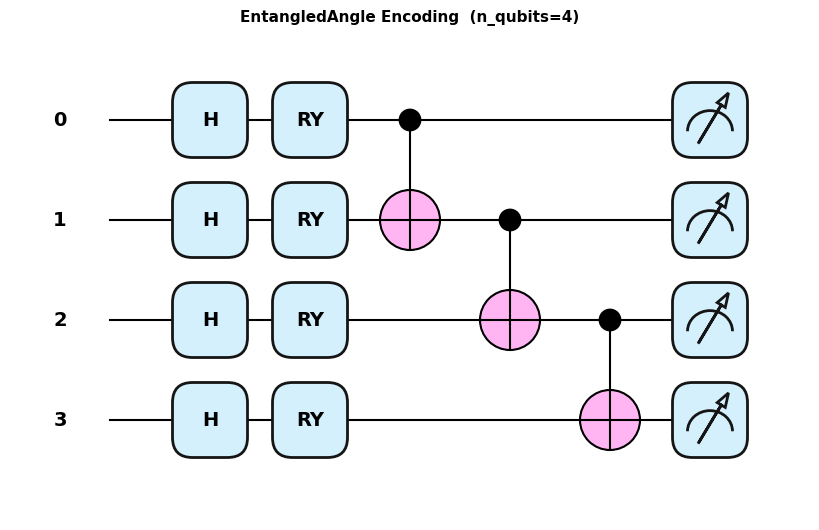

  Circuit depth for EntangledAngle: 5

=== Basis ===


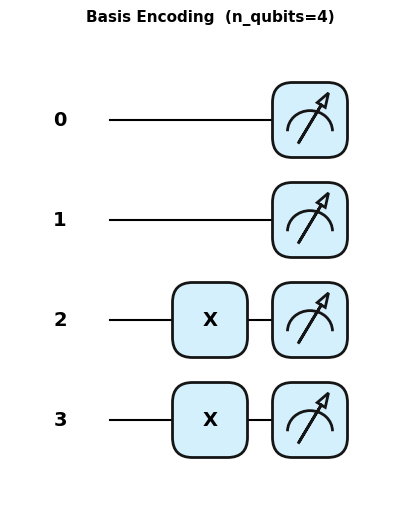

  Circuit depth for Basis: 1

=== Amplitude ===


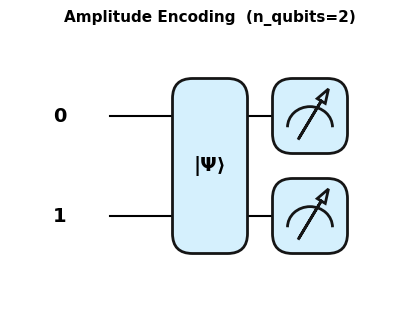

  Circuit depth for Amplitude: 1

=== DenseAngle ===


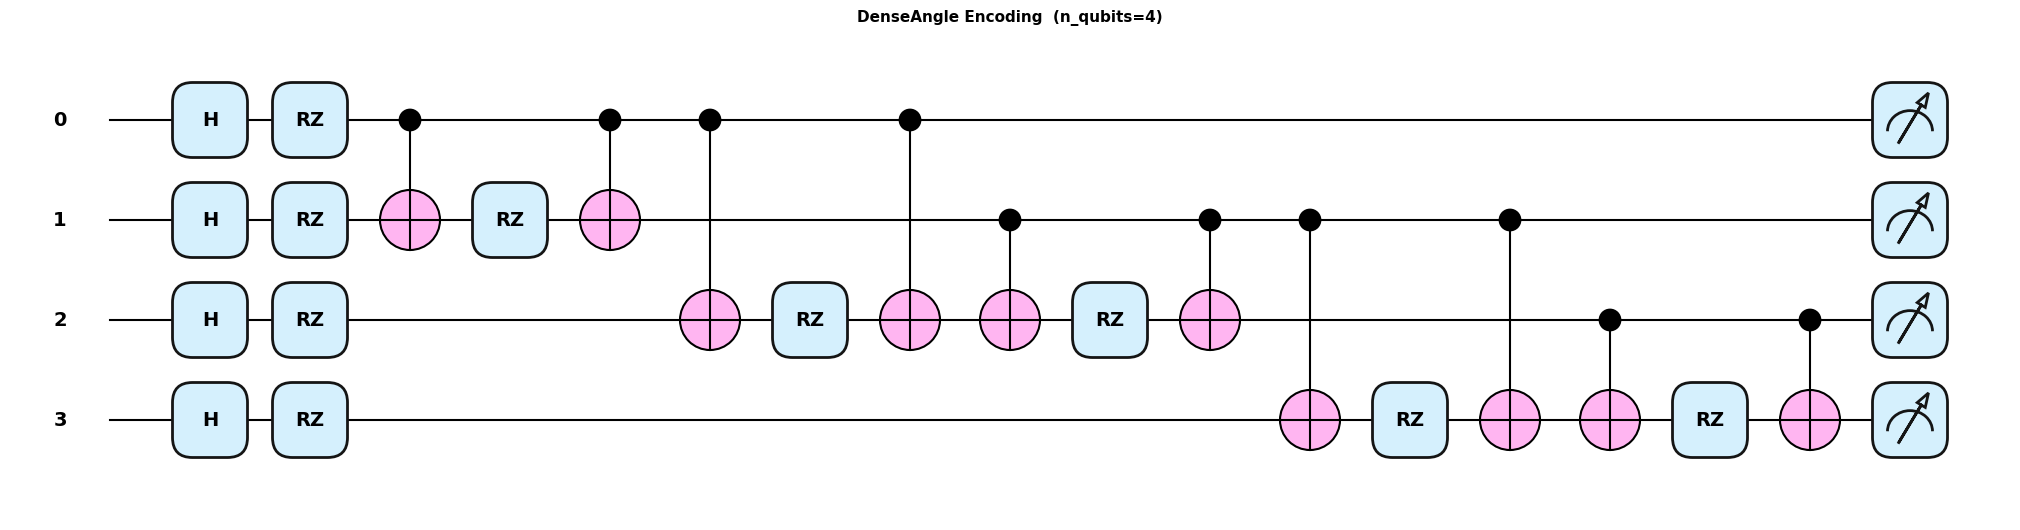

  Circuit depth for DenseAngle: 17

=== ShotBased ===


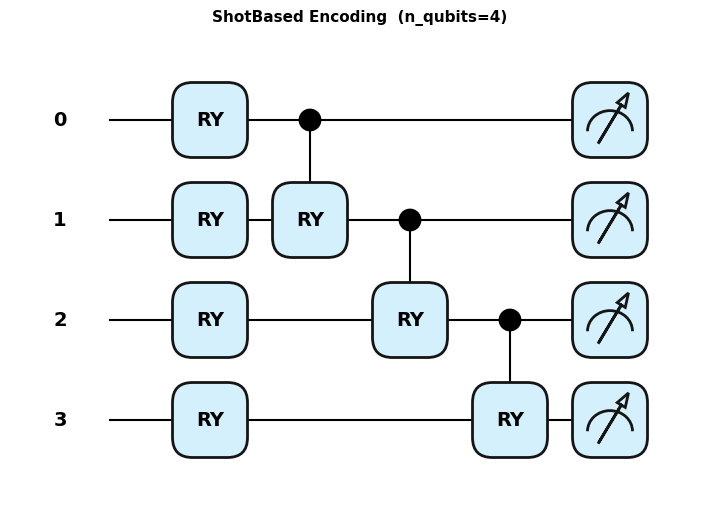

  Circuit depth for ShotBased: 4

=== FRQI ===


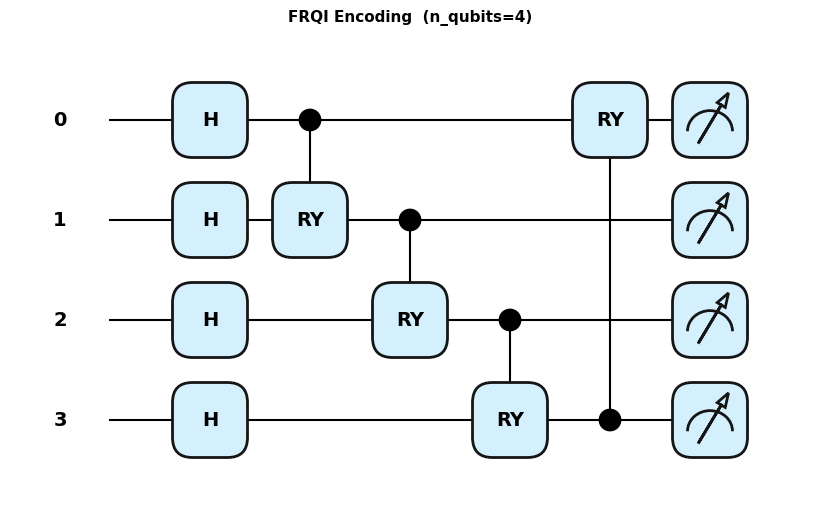

  Circuit depth for FRQI: 5

=== NEQR ===


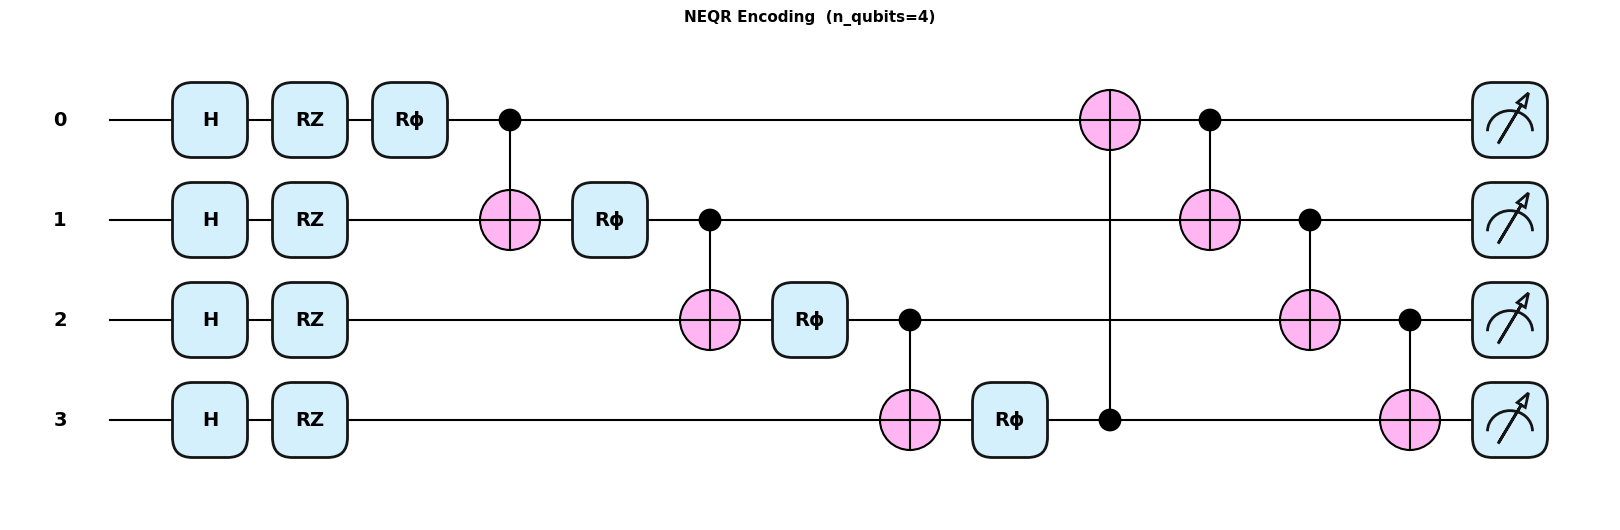

  Circuit depth for NEQR: 13

=== IQP ===


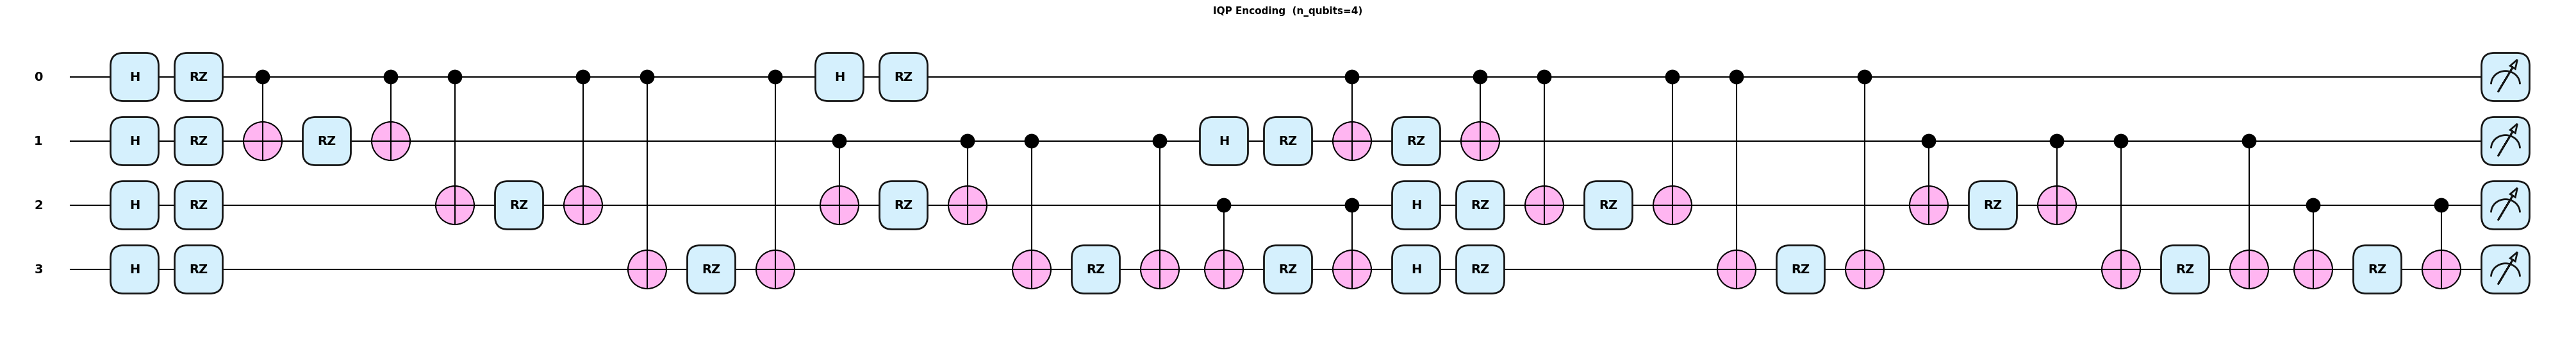

  Circuit depth for IQP: 31

=== QHE ===


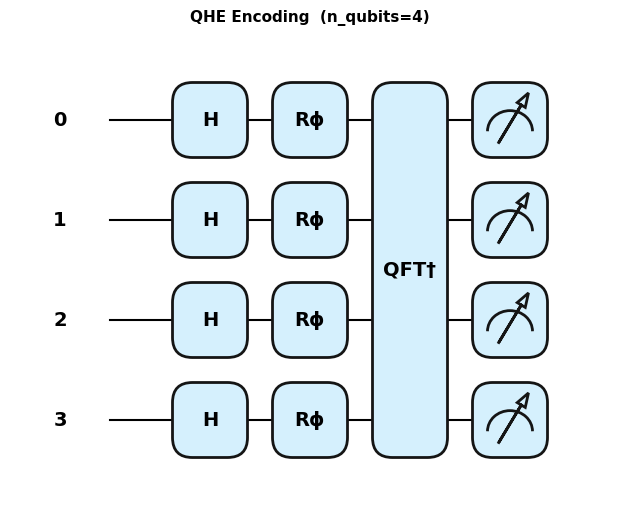

  Circuit depth for QHE: 3

=== Hamiltonian ===


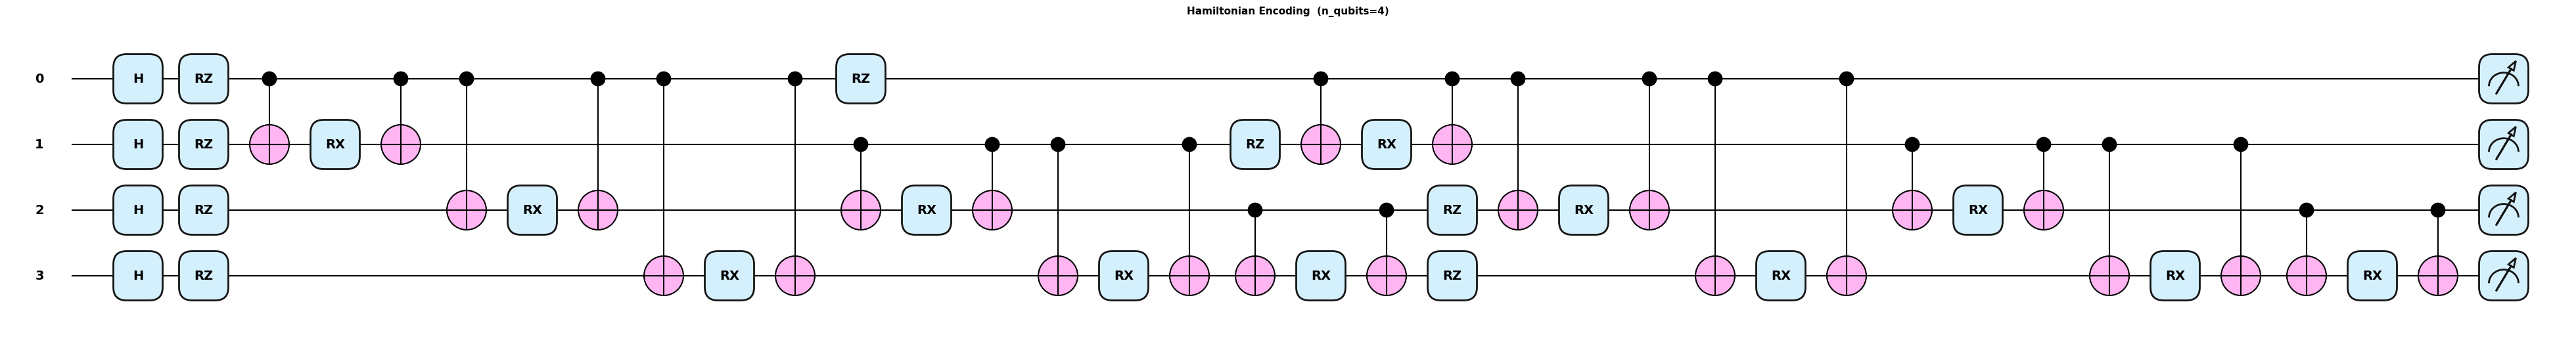

  Circuit depth for Hamiltonian: 30

=== GraphEncoding ===


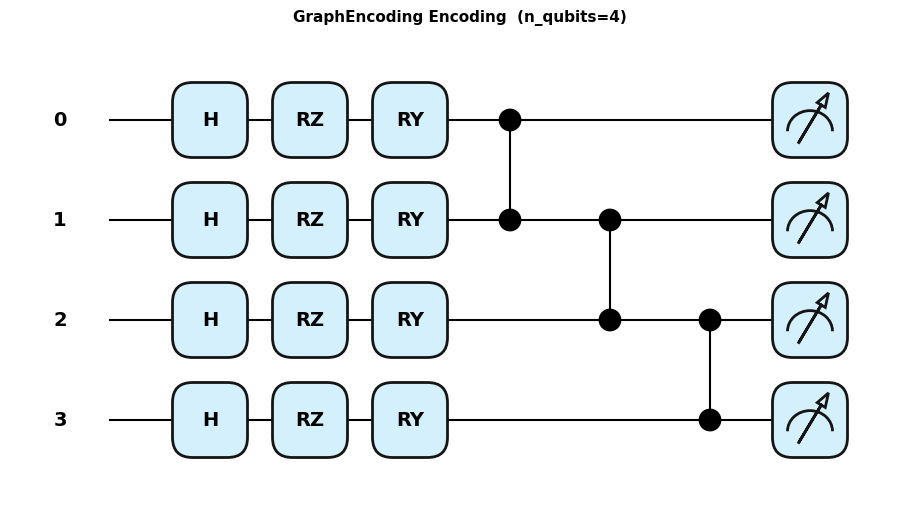

  Circuit depth for GraphEncoding: 6

=== AQHE_LogHelix ===


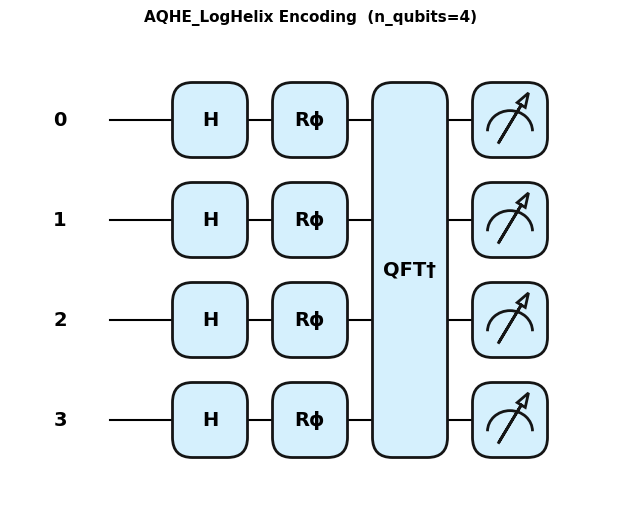

  Circuit depth for AQHE_LogHelix: 3

=== AQHE_FibSpiral ===


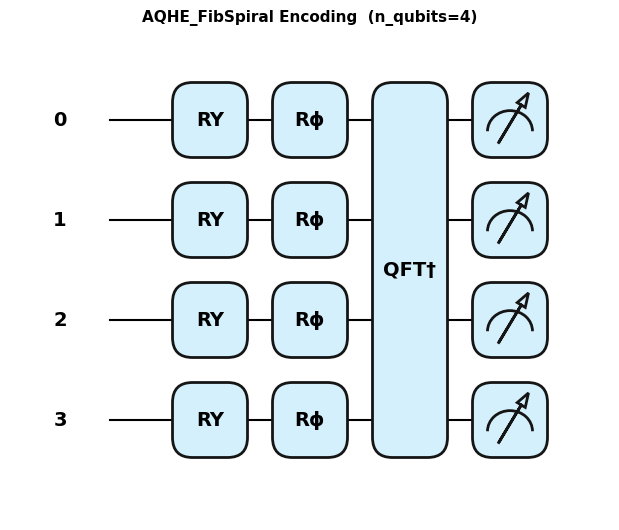

  Circuit depth for AQHE_FibSpiral: 3

=== AQHE_DualEnc ===


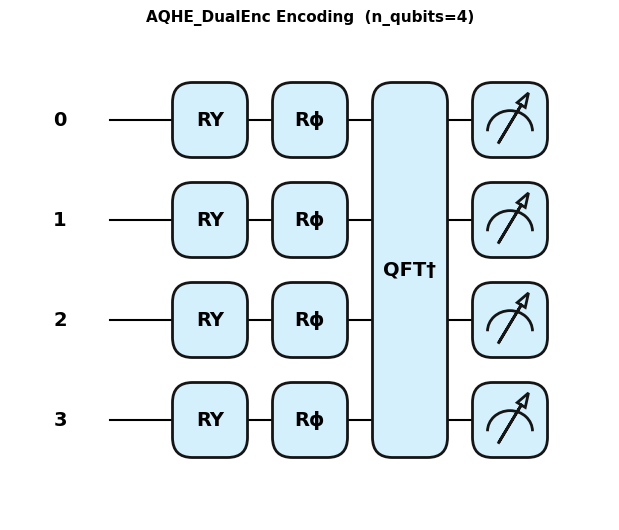

  Circuit depth for AQHE_DualEnc: 3

=== PCE ===


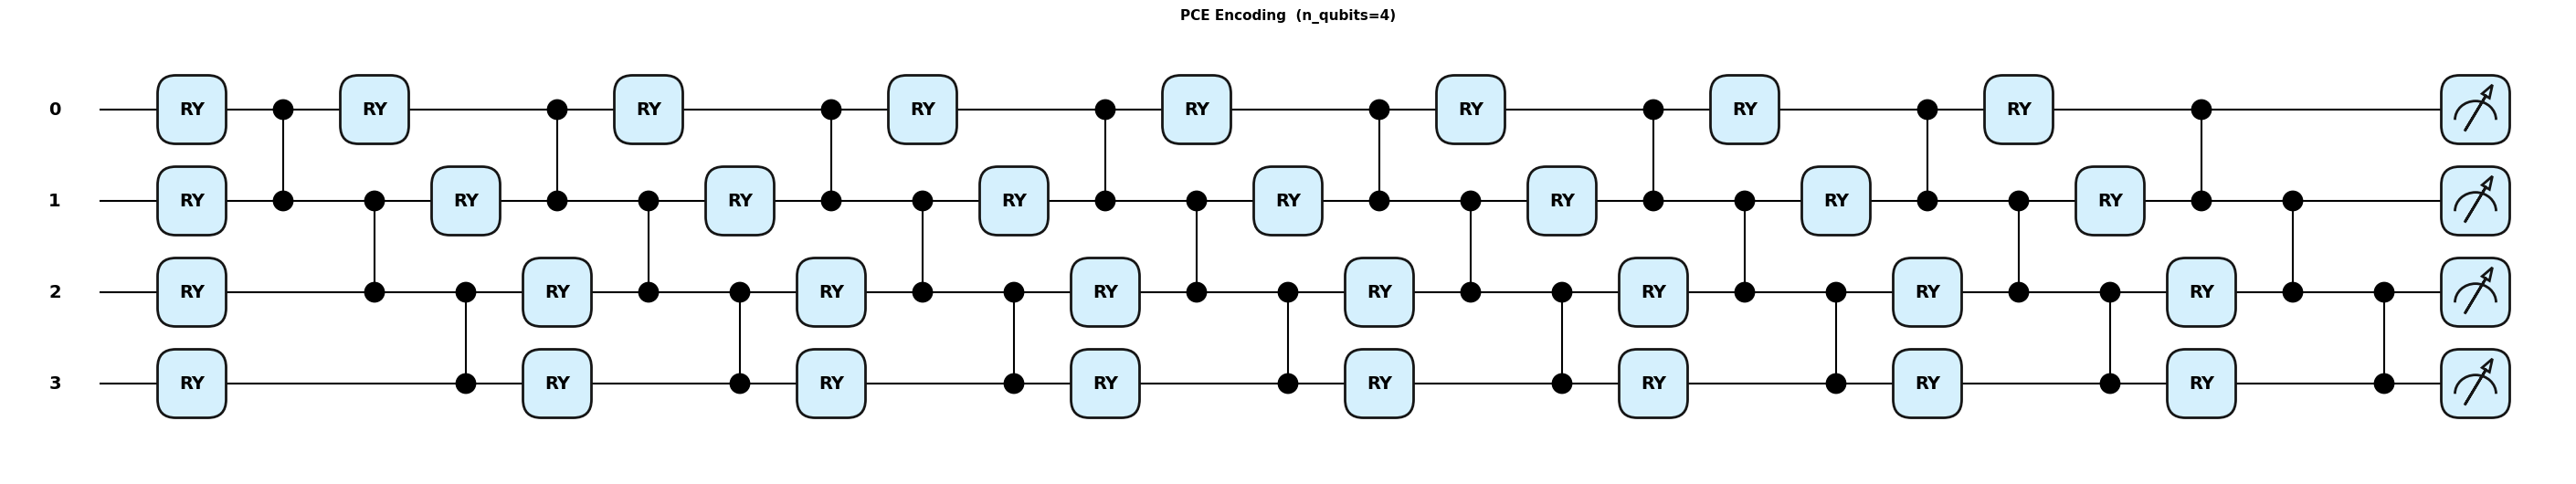

  Circuit depth for PCE: 25


In [7]:
def draw_circuit(enc_name, enc_fn, n_qubits=4, feature_dim=4):
    # Amplitude and AQHE variants may use fewer/different qubits
    if enc_name == "Amplitude":
        n_draw = max(1, int(np.ceil(np.log2(feature_dim))))
    elif enc_name in ("QHE", "AQHE_LogHelix", "AQHE_FibSpiral", "AQHE_DualEnc"):
        n_draw = n_qubits
    else:
        n_draw = n_qubits
    dev = get_device(n_draw)
    @qml.qnode(dev)
    def circuit(x):
        enc_fn(x, n_draw)
        return [qml.expval(qml.PauliZ(i)) for i in range(n_draw)]
    x_dummy = np.linspace(0.1, np.pi - 0.1, feature_dim)
    try:
        fig, ax = qml.draw_mpl(circuit, style="pennylane")(x_dummy)
        fig.suptitle(f"{enc_name} Encoding  (n_qubits={n_draw})", fontsize=11,
                     fontweight="bold", y=1.02)
        plt.tight_layout()
        safe_name = "".join(c if c.isalnum() or c in "_-" else "_" for c in enc_name)
        plt.savefig(OUTPUT_DIR / f"circuit_{safe_name}.png", dpi=130, bbox_inches="tight")
        plt.show()
        try:
            depth = qml.specs(circuit)(x_dummy)["resources"].depth
            print(f"  Circuit depth for {enc_name}: {depth}")
        except Exception:
            print(f"  Circuit depth for {enc_name}: (unavailable)")
    except Exception as e:
        print(f"  [draw failed for {enc_name}]: {e}")

for name, fn in ENCODING_FNS.items():
    print(f"\n=== {name} ===")
    draw_circuit(name, fn)


## 4 · Quantum Kernel (Parallelized)

Parallelized kernel computation via `joblib`. Falls back to serial automatically.
For multiclass SVM: `OneVsRestClassifier(SVC(kernel='precomputed', C=1.0))`.


In [8]:
def _kernel_row_worker(i_start, i_end, X1, X2, enc_fn, n_qubits, symmetric):
    dev = get_device(n_qubits)
    @qml.qnode(dev)
    def kernel_circuit(x1, x2):
        enc_fn(x1, n_qubits)
        qml.adjoint(enc_fn)(x2, n_qubits)
        return qml.probs(wires=range(n_qubits))
    n2 = len(X2)
    out = []
    for i in range(i_start, i_end):
        row = np.zeros(n2)
        jstart = i + 1 if symmetric else 0
        if symmetric:
            row[i] = 1.0
        for j in range(jstart, n2):
            try:
                row[j] = kernel_circuit(X1[i], X2[j])[0]
            except Exception:
                row[j] = 0.0
        out.append((i, row))
    return out


def build_kernel_matrix(X1, X2, enc_fn, n_qubits, symmetric=False, n_jobs=N_JOBS, verbose=False):
    """Quantum kernel matrix, parallelized. symmetric=True for train-train (~2x faster)."""    
    n1, n2 = len(X1), len(X2)
    n_workers = n_jobs if n_jobs and n_jobs > 0 else max(1, os.cpu_count() or 1)
    n_workers = max(1, min(n_workers, n1))
    t0 = time.time()
    try:
        if n_workers > 1:
            chunk = max(1, n1 // n_workers + (1 if n1 % n_workers else 0))
            chunks = [(s, min(s + chunk, n1)) for s in range(0, n1, chunk)]
            results = Parallel(n_jobs=n_workers, prefer="processes")(
                delayed(_kernel_row_worker)(s, e, X1, X2, enc_fn, n_qubits, symmetric)
                for s, e in chunks
            )
        else:
            results = [_kernel_row_worker(0, n1, X1, X2, enc_fn, n_qubits, symmetric)]
    except Exception as e:
        print(f"    [parallel kernel failed: {e} -- falling back to serial]")
        results = [_kernel_row_worker(0, n1, X1, X2, enc_fn, n_qubits, symmetric)]
    K = np.zeros((n1, n2))
    for chunk_res in results:
        for i, row in chunk_res:
            K[i, :] = row
    if symmetric:
        K = np.triu(K) + np.triu(K, 1).T
    if verbose:
        print(f"    kernel {n1}x{n2} (symmetric={symmetric}) in {time.time()-t0:.1f}s")
    return K


def estimate_kernel_eta(enc_fn, n_qubits, n_train, n_test, n_jobs=N_JOBS, n_calib=6):
    """Calibrate real per-pair cost and project ETA."""    
    dev = get_device(n_qubits)
    @qml.qnode(dev)
    def kc(x1, x2):
        enc_fn(x1, n_qubits)
        qml.adjoint(enc_fn)(x2, n_qubits)
        return qml.probs(wires=range(n_qubits))
    x_dummy = np.linspace(0.1, np.pi - 0.1, max(4, n_qubits))
    t0 = time.time()
    for _ in range(n_calib):
        try:
            kc(x_dummy, x_dummy)[0]
        except Exception:
            pass
    sec_per_eval = (time.time() - t0) / n_calib
    pairs_tr = n_train * (n_train + 1) // 2
    pairs_te = n_test * n_train
    n_workers = n_jobs if n_jobs and n_jobs > 0 else max(1, os.cpu_count() or 1)
    eff = min(n_workers, max(1, os.cpu_count() or 1)) * 0.7 if n_workers > 1 else 1
    eta_sec = (pairs_tr + pairs_te) * sec_per_eval / max(eff, 1)
    return eta_sec, sec_per_eval


def fit_multiclass_svm_kernel(K_tr, K_te, y_tr, y_te):
    """Fit OneVsRest SVM on precomputed kernels; return test accuracy."""    # Sanitize kernel
    K_tr = np.nan_to_num(K_tr, nan=0.0, posinf=1.0, neginf=0.0)
    K_te = np.nan_to_num(K_te, nan=0.0, posinf=1.0, neginf=0.0)
    K_tr = (K_tr + K_tr.T) / 2
    np.fill_diagonal(K_tr, 1.0)
    svm = OneVsRestClassifier(SVC(kernel="precomputed", C=1.0))
    svm.fit(K_tr, y_tr)
    preds = svm.predict(K_te)
    return accuracy_score(y_te, preds)


print("Parallel kernel builder + multiclass SVM defined.")


Parallel kernel builder + multiclass SVM defined.


## 5 · Variational Quantum Classifier (VQC) — 2-layer, Multiclass

VQC uses **2 StronglyEntanglingLayers** (reduced from 6 — see fixes below).
For multiclass: measures `expval(PauliZ(i))` on each qubit, applies softmax,
and trains with **mini-batch Adam** and cross-entropy loss for K-class classification.

**v11 VQC fixes (all caused near-chance accuracy in v10 graphs):**
- **Barren plateau**: 6 layers × 6 qubits → gradient variance ~10⁻¹¹ → reduced to 2 layers
- **Optimizer**: Vanilla GD → Adam (adaptive lr handles tiny gradients)
- **Mini-batching**: Full 1875-sample cost per step → random batch of 32 per step
- **Weight init**: Uniform[-π,π] (deep in plateau) → N(0,0.01) (near identity gate)


In [9]:
import pennylane.numpy as pnp
from math import ceil

def build_vqc_multiclass(enc_fn, n_qubits, n_classes, n_layers=VQC_LAYERS):
    """Build a multiclass VQC with enc_fn closed over (not passed as arg).
    Uses default.qubit + parameter-shift for correct autograd gradients.
    """
    dev = qml.device("default.qubit", wires=n_qubits)
    n_params = n_layers * n_qubits * 3

    @qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
    def vqc_circuit(x, weights):
        enc_fn(x, n_qubits)
        w = weights.reshape(n_layers, n_qubits, 3)
        qml.StronglyEntanglingLayers(w, wires=range(n_qubits))
        return tuple(qml.expval(qml.PauliZ(i)) for i in range(n_qubits))

    return vqc_circuit, n_params


def _softmax(z):
    z = pnp.array(z)
    z = z - pnp.max(z, axis=-1, keepdims=True)
    e = pnp.exp(z)
    return e / pnp.sum(e, axis=-1, keepdims=True)


def train_vqc_multiclass(enc_fn, Xtr, ytr, Xte, yte,
                          n_qubits=N_QUBITS, n_layers=VQC_LAYERS,
                          n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                          lr=STEP_SIZE, verbose=True):
    """Train multiclass VQC.

    Train/val/test protocol
    -----------------------
    Xtr/ytr are split 80/20 into train and validation INSIDE this function.
    Xte/yte (the test set) are kept COMPLETELY UNSEEN during training.
    After all epochs are done, the final weights are evaluated ONCE on Xte.

    Epoch definition (fixed)
    ------------------------
    One epoch = ceil(n_train / batch_size) gradient steps, i.e. a full pass
    through the training data in random mini-batches.
    Previously there was 1 step per epoch, giving only 30 weight updates total
    for 30 epochs. With n_train=360 and batch_size=32 this is now 12 steps/epoch
    → 360 total updates for 30 epochs, 15× more training signal.
    """
    n_classes = len(np.unique(np.concatenate([ytr, yte])))

    # ── 1. Carve out validation set (20% of Xtr) ────────────────────────────
    val_size   = max(1, int(0.2 * len(Xtr)))
    val_idx    = rng.choice(len(Xtr), size=val_size, replace=False)
    train_mask = np.ones(len(Xtr), dtype=bool)
    train_mask[val_idx] = False

    Xval, yval   = Xtr[val_idx],    ytr[val_idx]
    Xtr2, ytr2   = Xtr[train_mask], ytr[train_mask]
    n_train      = len(Xtr2)
    steps_per_ep = max(1, ceil(n_train / batch_size))

    if verbose:
        print(f"  Split: {n_train} train | {val_size} val | {len(Xte)} test (unseen)")
        print(f"  Steps/epoch: {steps_per_ep}  (batch={batch_size})")

    # ── 2. Build circuit and initialise weights ──────────────────────────────
    vqc, n_params = build_vqc_multiclass(enc_fn, n_qubits, n_classes, n_layers)
    weights = pnp.array(rng.normal(0, 0.01, n_params), requires_grad=True)
    opt     = qml.AdamOptimizer(stepsize=lr)

    tr_acc_hist, val_acc_hist = [], []

    # ── 3. Helpers ───────────────────────────────────────────────────────────
    def _get_logits(X, w):
        raw   = np.array([np.array(vqc(x, w)) for x in X])   # [N, n_qubits]
        n_out = raw.shape[1]
        if n_out >= n_classes:
            return raw[:, :n_classes]
        pad = np.full((raw.shape[0], n_classes - n_out), -1.0)
        return np.concatenate([raw, pad], axis=1)

    def _predict(X, w):
        logits = _get_logits(X, w)
        logits = logits - np.max(logits, axis=1, keepdims=True)
        exp_l  = np.exp(logits)
        proba  = exp_l / np.sum(exp_l, axis=1, keepdims=True)
        return np.argmax(proba, axis=1)

    # ── 4. Training loop ─────────────────────────────────────────────────────
    for epoch in range(n_epochs):
        # Shuffle training data for this epoch
        perm = rng.permutation(n_train)
        Xtr2_shuf, ytr2_shuf = Xtr2[perm], ytr2[perm]

        epoch_loss = 0.0
        for step in range(steps_per_ep):
            s = step * batch_size
            e = min(s + batch_size, n_train)
            X_batch = Xtr2_shuf[s:e]
            y_batch = ytr2_shuf[s:e]

            # Close over batch so w is the only differentiable arg
            def cost(w):
                raw   = pnp.stack([vqc(x, w) for x in X_batch])
                n_out = raw.shape[1]
                if n_out >= n_classes:
                    logits_cls = raw[:, :n_classes]
                else:
                    pad        = pnp.zeros((raw.shape[0], n_classes - n_out))
                    logits_cls = pnp.concatenate([raw, pad], axis=1)
                proba   = _softmax(logits_cls)
                one_hot = pnp.eye(n_classes)[y_batch]
                return -pnp.mean(pnp.sum(one_hot * pnp.log(proba + 1e-9), axis=1))

            weights, loss_val = opt.step_and_cost(cost, weights)
            epoch_loss += float(loss_val)

        # Evaluate on train and val (NOT test)
        tr_acc  = accuracy_score(ytr2,  _predict(Xtr2, weights))
        val_acc = accuracy_score(yval,  _predict(Xval, weights))
        tr_acc_hist.append(tr_acc)
        val_acc_hist.append(val_acc)

        if verbose and (epoch + 1) % 5 == 0:
            avg_loss = epoch_loss / steps_per_ep
            print(f"  Epoch {epoch+1:3d}/{n_epochs}  loss={avg_loss:.4f}  "
                  f"tr_acc={tr_acc:.3f}  val_acc={val_acc:.3f}")

    # ── 5. Final evaluation on UNSEEN test set (once, after all training) ────
    te_preds = _predict(Xte, weights)
    te_acc   = accuracy_score(yte, te_preds)
    if verbose:
        print(f"  → Final test acc (unseen): {te_acc:.4f}")

    # Return val_acc_hist as the "te_hist" slot so existing plot code works,
    # and store final test acc separately in the last element
    # te_hist[-1] used by benchmark cell for vqc_acc -> use actual te_acc
    te_hist_out = val_acc_hist[:-1] + [te_acc]   # all val, last point = real test

    return weights, tr_acc_hist, te_hist_out


print(f"VQC helpers defined (v11 — train/val/test split, full epoch pass).")
print(f"  Device       : default.qubit + diff_method=parameter-shift")
print(f"  Optimizer    : AdamOptimizer(lr={STEP_SIZE})")
print(f"  VQC_LAYERS   : {VQC_LAYERS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Steps/epoch  : ceil(n_train / batch_size)  [full data pass per epoch]")
print(f"  Val split    : 20% of Xtr  [used for epoch monitoring]")
print(f"  Test set     : evaluated ONCE after all epochs complete")
print(f"  Weight init  : N(0, 0.01)")

VQC helpers defined (v11 — train/val/test split, full epoch pass).
  Device       : default.qubit + diff_method=parameter-shift
  Optimizer    : AdamOptimizer(lr=0.01)
  VQC_LAYERS   : 2
  Batch size   : 32
  Steps/epoch  : ceil(n_train / batch_size)  [full data pass per epoch]
  Val split    : 20% of Xtr  [used for epoch monitoring]
  Test set     : evaluated ONCE after all epochs complete
  Weight init  : N(0, 0.01)


## 6 · Main Benchmark: All Encodings × All Datasets (Multiclass SVM)

Prints calibrated ETA before running. Multiclass accuracy via OneVsRest SVM on quantum kernels.


In [10]:
RUN_VQC    = False  # set True for VQC epoch curves (much slower)
RUN_KERNEL = True

def estimate_kernel_eta(enc_fn, n_qubits, n_train, n_test, n_sample=3):
    """Time a few kernel entries to estimate total runtime."""
    dev  = get_device(n_qubits)
    x_dummy = np.random.uniform(0, np.pi, n_qubits)
    @qml.qnode(dev)
    def _circ(x): enc_fn(x, n_qubits); return qml.state()
    t0 = time.time()
    for _ in range(n_sample): _circ(x_dummy)
    per_pair = (time.time() - t0) / n_sample
    n_pairs  = n_train*(n_train+1)//2 + n_test*n_train
    return per_pair * n_pairs, per_pair


def fit_multiclass_svm_kernel(K_tr, K_te, y_tr, y_te, C=1.0):
    """OneVsRest SVM with precomputed kernel."""
    clf = OneVsRestClassifier(SVC(kernel='precomputed', C=C))
    clf.fit(K_tr, y_tr)
    return accuracy_score(y_te, clf.predict(K_te))


print("Calibrating runtime estimate for the main benchmark ...")
ds_name = "CIFAR10_10cls"
Xtr_main, Xte_main, ytr_main, yte_main = data[ds_name]
total_eta = 0
for enc_name, enc_fn in ENCODING_FNS.items():
    try:
        nq = N_QUBITS
        # Use PCE data dimensions for calibration of PCE encoding
        Xtr_cal = data_pce[ds_name][0] if ENCODING_DATA_SOURCE[enc_name] == 'pce' else Xtr_main
        Xte_cal = data_pce[ds_name][1] if ENCODING_DATA_SOURCE[enc_name] == 'pce' else Xte_main
        eta, _ = estimate_kernel_eta(enc_fn, nq, len(Xtr_cal), len(Xte_cal))
        total_eta += eta
    except Exception:
        pass
print(f"  -> Estimated total: ~{total_eta/60:.1f} min (~{total_eta/3600:.2f} hr) "
      f"using {N_CORES} worker(s)")
print(f"  -> {len(ENCODING_FNS)} encodings x 1 dataset")

results = {ds_name: {}}

if RUN_KERNEL:
    print("\n" + "="*65)
    print(f"  DATASET: {ds_name}  (train={len(Xtr_main)}, test={len(Xte_main)},"
          f" 10 classes)  [{data_source[ds_name]}]")
    print("="*65)

    for enc_name, enc_fn in ENCODING_FNS.items():
        # ── Route to correct data pipeline ──────────────────────────────
        if ENCODING_DATA_SOURCE[enc_name] == 'pce':
            Xtr_enc, Xte_enc, ytr_enc, yte_enc = data_pce[ds_name]
            note = f" [PCA-{pipe_b['n_pca']}, 64-dim]"
        else:
            Xtr_enc, Xte_enc, ytr_enc, yte_enc = data[ds_name]
            note = f" [LDA-{pipe['n_lda']}]"

        t0 = time.time()
        try:
            K_tr = build_kernel_matrix(Xtr_enc, Xtr_enc, enc_fn, N_QUBITS, symmetric=True)
            K_te = build_kernel_matrix(Xte_enc, Xtr_enc, enc_fn, N_QUBITS, symmetric=False)
            svm_acc = fit_multiclass_svm_kernel(K_tr, K_te, ytr_enc, yte_enc)
            elapsed = time.time() - t0
            results[ds_name][enc_name] = {"svm_acc": svm_acc, "time": elapsed}
            tag = " ← PCE (64-dim PCA)" if enc_name == "PCE" else ""
            print(f"   Encoding: {enc_name:<18}  SVM (OneVsRest) acc = "
                  f"{svm_acc:.3f}  ({elapsed:.1f}s){note}{tag}")
        except Exception as e:
            results[ds_name][enc_name] = {"svm_acc": np.nan, "time": 0}
            print(f"   Encoding: {enc_name:<18}  FAILED: {e}")

        if RUN_VQC:
            try:
                # VQC only on LDA data (8-dim); PCE VQC not supported
                if ENCODING_DATA_SOURCE[enc_name] != 'pce':
                    vqc_acc, epoch_accs = build_vqc_multiclass(
                        enc_fn, N_QUBITS, N_CLASSES, Xtr_enc, ytr_enc,
                        Xte_enc, yte_enc, N_EPOCHS, BATCH_SIZE, STEP_SIZE, VQC_LAYERS)
                    results[ds_name][enc_name]["vqc_acc"]    = vqc_acc
                    results[ds_name][enc_name]["epoch_accs"] = epoch_accs
                    print(f"     VQC acc = {vqc_acc:.3f}")
            except Exception as e:
                print(f"     VQC FAILED: {e}")
                results[ds_name][enc_name]["vqc_acc"] = np.nan

print("\nMain benchmark complete.")


Calibrating runtime estimate for the main benchmark ...
  -> Estimated total: ~208.5 min (~3.47 hr) using 16 worker(s)
  -> 18 encodings x 1 dataset

  DATASET: CIFAR10_10cls  (train=450, test=150, 10 classes)  [REAL-torchvision]
   Encoding: Rotational          SVM (OneVsRest) acc = 0.300  (44.9s) [LDA-8]
   Encoding: SimpleAngle         SVM (OneVsRest) acc = 0.300  (45.8s) [LDA-8]
   Encoding: Pi4Angle            SVM (OneVsRest) acc = 0.293  (50.1s) [LDA-8]
   Encoding: EntangledAngle      SVM (OneVsRest) acc = 0.300  (174.2s) [LDA-8]
   Encoding: Basis               SVM (OneVsRest) acc = 0.207  (132.1s) [LDA-8]
   Encoding: Amplitude           SVM (OneVsRest) acc = 0.260  (284.5s) [LDA-8]
   Encoding: DenseAngle          SVM (OneVsRest) acc = 0.273  (430.6s) [LDA-8]
   Encoding: ShotBased           SVM (OneVsRest) acc = 0.247  (71.0s) [LDA-8]
   Encoding: FRQI                SVM (OneVsRest) acc = 0.300  (62.1s) [LDA-8]
   Encoding: NEQR                SVM (OneVsRest) acc = 0.267  (9

## 7 · Accuracy per Epoch (VQC — Multiclass)

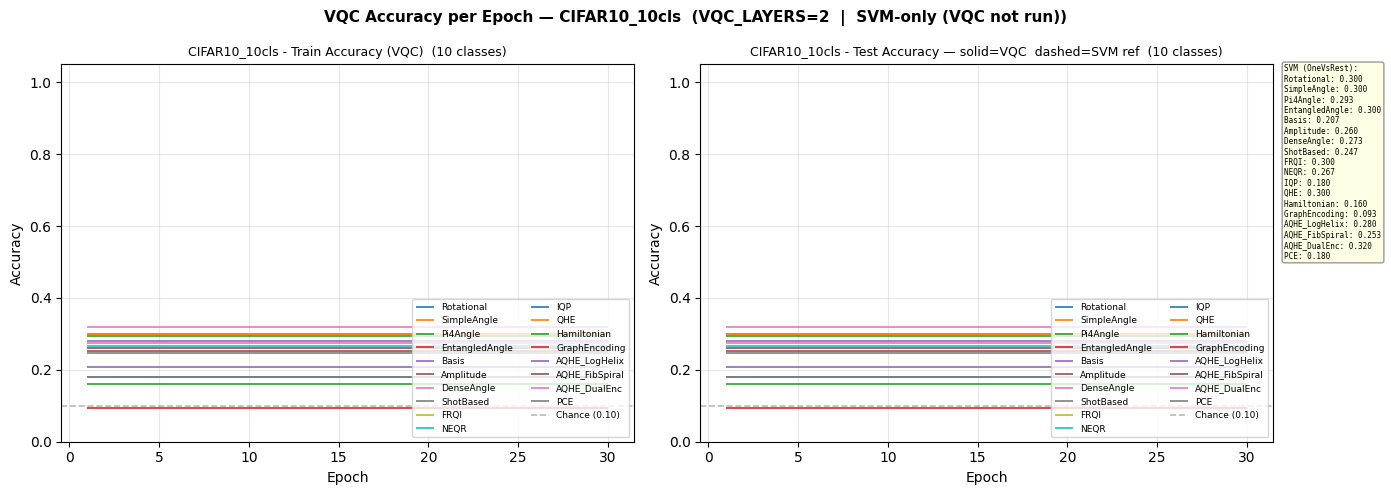

In [11]:
def plot_accuracy_curves(results, dataset):
    ds_res = results.get(dataset, {})
    has_vqc = any(len(v.get("te_hist", [])) > 0 for v in ds_res.values())
    n_cls = len(np.unique(np.concatenate([data[dataset][2], data[dataset][3]])))
    chance = 1.0 / n_cls

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    enc_names = list(ds_res.keys())

    for i, (enc_name, row) in enumerate(ds_res.items()):
        color = color_cycle[i % len(color_cycle)]
        svm_acc = row.get("svm_acc", None)   # horizontal SVM reference per encoding
        tr_h    = row.get("tr_hist", [])
        te_h    = row.get("te_hist", [])

        if has_vqc and len(te_h) > 0:
            epochs = np.arange(1, len(te_h) + 1)
            axes[0].plot(epochs, tr_h, label=enc_name, linewidth=1.3, color=color)
            axes[1].plot(epochs, te_h, label=enc_name, linewidth=1.3, color=color)

            # Overlay SVM accuracy as a dashed horizontal line on the test panel
            if svm_acc is not None:
                axes[1].hlines(svm_acc, xmin=1, xmax=len(te_h),
                               colors=color, linestyles='dashed',
                               linewidth=0.9, alpha=0.6)
        else:
            # VQC not run — plot SVM acc as a single marker/flat line on both panels
            if svm_acc is not None:
                for ax in axes:
                    ax.hlines(svm_acc, xmin=1, xmax=N_EPOCHS,
                              colors=color, linestyles='solid',
                              linewidth=1.4, label=enc_name, alpha=0.85)

    # Chance line
    for ax, title in zip(axes, ["Train Accuracy (VQC)", "Test Accuracy — solid=VQC  dashed=SVM ref"]):
        ax.axhline(chance, color="gray", linestyle="--", linewidth=1.2,
                   alpha=0.55, label=f"Chance ({chance:.2f})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{dataset} - {title}  ({n_cls} classes)", fontsize=9)
        ax.legend(fontsize=6.5, ncol=2, loc="lower right")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    # Add SVM summary text box on the right panel
    svm_lines = [f"{enc}: {row.get('svm_acc', float('nan')):.3f}"
                 for enc, row in ds_res.items() if row.get('svm_acc') is not None]
    if svm_lines:
        summary_txt = "SVM (OneVsRest):\n" + "\n".join(svm_lines)
        axes[1].text(1.02, 1.0, summary_txt, transform=axes[1].transAxes,
                     fontsize=5.5, verticalalignment='top',
                     fontfamily='monospace',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                               alpha=0.8, edgecolor='gray'))

    fig.suptitle(
        f"VQC Accuracy per Epoch — {dataset}  "
        f"(VQC_LAYERS={VQC_LAYERS}{'  |  dashed = SVM reference' if has_vqc else '  |  SVM-only (VQC not run)'})",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    safe_ds = dataset.replace("/", "_").replace(" ", "_")
    plt.savefig(OUTPUT_DIR / f"epoch_curves_{safe_ds}.png", dpi=140, bbox_inches="tight")
    plt.show()

for ds in DATASETS:
    plot_accuracy_curves(results, ds)

## 8 · Qubit Count Variation (2 → 8, All Encodings)

Tests every encoding across the full qubit range on **CIFAR10_10cls**.
For each qubit count `nq`, LDA is refit with `n_components=nq` (max=min(nq, 9)).
Note: Amplitude encoding's effective qubit count is fixed by feature dimensionality.


Qubit sweep on CIFAR10_10cls (CIFAR-10, 10 classes, PCA+LDA refitted per nq) ...
Calibrating ETA for qubit sweep ...
  -> Estimated total: ~980.8 min (~16.35 hr)

  n_qubits = 2
Files already downloaded and verified
Files already downloaded and verified
  [CIFAR10_10cls] loaded via torchvision (RGB, 3072-d)
  [CIFAR10_10cls] REAL-torchvision
    Pipeline A (LDA): PCA-50 (var=86.7%) → LDA-2 → shape (450, 2)
    Pipeline B (PCE): PCA-64 (var=89.2%) → shape (450, 64)
    Rotational         -> 0.227
    SimpleAngle        -> 0.227
    Pi4Angle           -> 0.187
    EntangledAngle     -> 0.227
    Basis              -> 0.100
    Amplitude          -> 0.100
    DenseAngle         -> 0.207
    ShotBased          -> 0.093
    FRQI               -> 0.180
    NEQR               -> 0.193
    IQP                -> 0.140
    QHE                -> 0.227
    Hamiltonian        -> 0.180
    GraphEncoding      -> 0.100
    AQHE_LogHelix      -> 0.200
    AQHE_FibSpiral     -> 0.213
    AQHE_DualEnc   

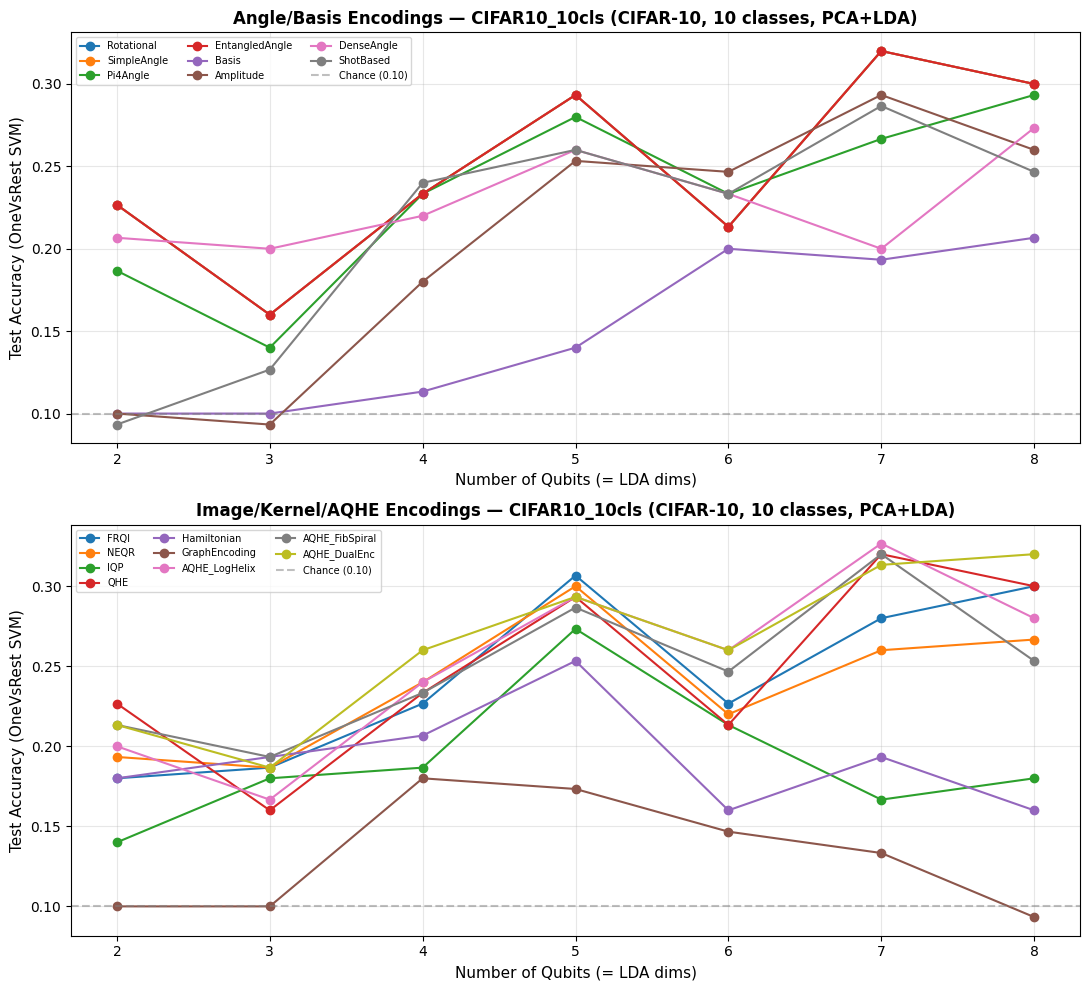

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce\qubit_sweep_cifar10_lda.png


In [12]:
SWEEP_ENC = [e for e in ENCODING_FNS.keys() if e != "PCE"]
# NOTE: PCE is excluded from this sweep. PCE uses a fixed PCA-64 -> 8-qubit
# HEA pipeline (Pipeline B); "n_qubits = LDA dims" does not apply to it, and
# its p_layers is derived from PCE_N_QUBITS=8, not from the swept nq value.
SWEEP_DS  = "CIFAR10_10cls"

# For the qubit sweep we reload CIFAR-10 raw data once and refit LDA per nq
print(f"Qubit sweep on {SWEEP_DS} (CIFAR-10, 10 classes, PCA+LDA refitted per nq) ...")

# Retrieve raw (pre-LDA) data by re-running loader at max dims
# We use the already-loaded data[SWEEP_DS] as baseline (LDA-{DEFAULT_LDA})
# and for each nq != DEFAULT_LDA we call load_cifar10_multiclass(lda_dims=nq)

qubit_results = {enc: [] for enc in SWEEP_ENC}

print(f"Calibrating ETA for qubit sweep ...")
total_eta_sweep = 0
Xtr_base, Xte_base, ytr_base, yte_base = data[SWEEP_DS]
n_cls_sw = len(np.unique(np.concatenate([ytr_base, yte_base])))
for nq in QUBIT_SWEEP:
    for enc_name in SWEEP_ENC:
        try:
            eta, _ = estimate_kernel_eta(ENCODING_FNS[enc_name], nq,
                                         len(Xtr_base), len(Xte_base))
            total_eta_sweep += eta
        except Exception:
            pass
print(f"  -> Estimated total: ~{total_eta_sweep/60:.1f} min (~{total_eta_sweep/3600:.2f} hr)\n")

t_start_sweep = time.time()
for nq in QUBIT_SWEEP:
    print(f"  n_qubits = {nq}")
    # Refit PCA+LDA with lda_dims=nq for this qubit count
    lda_nq = min(nq, N_CLASSES - 1)
    if lda_nq == DEFAULT_LDA:
        Xtr_sw, Xte_sw, ytr_sw, yte_sw = data[SWEEP_DS]
    else:
        Xtr_sw, Xte_sw, ytr_sw, yte_sw, _, _, _, _, _ = load_cifar10_multiclass(lda_dims=lda_nq)
        # FIX: load_cifar10_multiclass() now returns 9 values (v3 added the PCE
        # Pipeline-B outputs Xtr_pce, Xte_pce, pipe_b). The old 6-value unpack from
        # v2 raised "ValueError: too many values to unpack (expected 6)" and halted
        # the whole notebook here, so every cell after this one never ran.

    for enc_name in SWEEP_ENC:
        enc_fn = ENCODING_FNS[enc_name]
        try:
            K_tr = build_kernel_matrix(Xtr_sw, Xtr_sw, enc_fn, nq, symmetric=True)
            K_te = build_kernel_matrix(Xte_sw, Xtr_sw, enc_fn, nq, symmetric=False)
            acc  = fit_multiclass_svm_kernel(K_tr, K_te, ytr_sw, yte_sw)
            qubit_results[enc_name].append(acc)
            print(f"    {enc_name:18s} -> {acc:.3f}")
        except Exception as e:
            qubit_results[enc_name].append(np.nan)
            print(f"    {enc_name:18s} -> FAILED: {e}")

print(f"\nQubit sweep done in {(time.time()-t_start_sweep)/60:.1f} min.")

fig, axes = plt.subplots(2, 1, figsize=(11, 10))
groups = [
    ("Angle/Basis Encodings",
     ["Rotational","SimpleAngle","Pi4Angle","EntangledAngle","Basis","Amplitude","DenseAngle","ShotBased"]),
    ("Image/Kernel/AQHE Encodings",
     ["FRQI","NEQR","IQP","QHE","Hamiltonian","GraphEncoding","AQHE_LogHelix","AQHE_FibSpiral","AQHE_DualEnc"]),
]
chance = 1.0 / n_cls_sw
for ax, (title, group) in zip(axes, groups):
    for enc_name in group:
        if enc_name in qubit_results:
            vals = qubit_results[enc_name]
            ax.plot(QUBIT_SWEEP[:len(vals)], vals, marker="o", label=enc_name, linewidth=1.5)
    ax.axhline(chance, color="gray", linestyle="--", alpha=0.5, label=f"Chance ({chance:.2f})")
    ax.set_xlabel("Number of Qubits (= LDA dims)", fontsize=11)
    ax.set_ylabel("Test Accuracy (OneVsRest SVM)", fontsize=11)
    ax.set_title(f"{title} — {SWEEP_DS} (CIFAR-10, 10 classes, PCA+LDA)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=7, ncol=3); ax.grid(alpha=0.3)
    ax.set_xticks(QUBIT_SWEEP)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qubit_sweep_cifar10_lda.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "qubit_sweep_cifar10_lda.png")


## 9 · LDA Dimensionality Sensitivity Analysis

Tests how accuracy varies as we increase the number of LDA discriminant components
(= qubit count). LDA is refit fresh at each dimensionality.
Maximum is K−1 = 9 for 10 classes; we test 2, 4, 6, 8.


LDA dimension sensitivity (CIFAR10_10cls, PCA+LDA pipeline) ...
Files already downloaded and verified
Files already downloaded and verified
  [CIFAR10_10cls] loaded via torchvision (RGB, 3072-d)
  [CIFAR10_10cls] REAL-torchvision
    Pipeline A (LDA): PCA-50 (var=86.4%) → LDA-8 → shape (450, 8)
    Pipeline B (PCE): PCA-64 (var=88.9%) → shape (450, 64)
  LDA= 8  n_qubits=8  Rotational         -> 0.327
  LDA= 8  n_qubits=8  QHE                -> 0.327
  LDA= 8  n_qubits=8  IQP                -> 0.160
  LDA= 8  n_qubits=8  Hamiltonian        -> 0.173
Files already downloaded and verified
Files already downloaded and verified
  [CIFAR10_10cls] loaded via torchvision (RGB, 3072-d)
  [CIFAR10_10cls] REAL-torchvision
    Pipeline A (LDA): PCA-50 (var=86.7%) → LDA-9 → shape (450, 9)
    Pipeline B (PCE): PCA-64 (var=89.1%) → shape (450, 64)
  LDA= 9  n_qubits=9  Rotational         -> 0.300
  LDA= 9  n_qubits=9  QHE                -> 0.300
  LDA= 9  n_qubits=9  IQP                -> 0.207
  LD

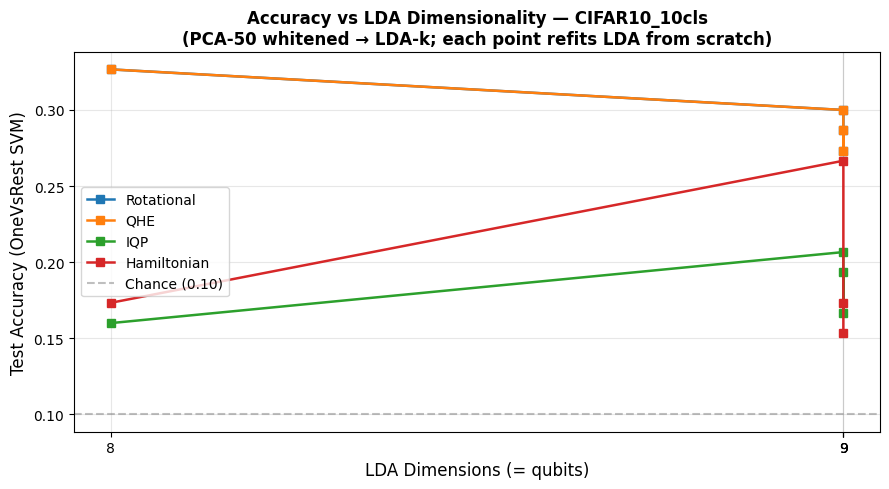

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce\lda_sensitivity_cifar10.png


In [13]:
PCA_SWEEP_ENC = ["Rotational", "QHE", "IQP", "Hamiltonian"]
lda_results   = {enc: [] for enc in PCA_SWEEP_ENC}
lda_dim_used  = []

print("LDA dimension sensitivity (CIFAR10_10cls, PCA+LDA pipeline) ...")
for ldim in PCA_DIMS:
    lda_nq = min(ldim, N_CLASSES - 1)
    Xtr_p, Xte_p, ytr_p, yte_p, _src, _pipe, _, _, _ = load_cifar10_multiclass(lda_dims=lda_nq)
    # FIX: same 9-value return as above (was a 6-value unpack in v2).
    lda_dim_used.append(lda_nq)
    nq = lda_nq
    for enc_name in PCA_SWEEP_ENC:
        enc_fn = ENCODING_FNS[enc_name]
        try:
            K_tr = build_kernel_matrix(Xtr_p, Xtr_p, enc_fn, nq, symmetric=True)
            K_te = build_kernel_matrix(Xte_p, Xtr_p, enc_fn, nq, symmetric=False)
            acc  = fit_multiclass_svm_kernel(K_tr, K_te, ytr_p, yte_p)
            lda_results[enc_name].append(acc)
            print(f"  LDA={lda_nq:2d}  n_qubits={nq}  {enc_name:18s} -> {acc:.3f}")
        except Exception as e:
            lda_results[enc_name].append(np.nan)
            print(f"  LDA={lda_nq:2d}  n_qubits={nq}  {enc_name:18s} -> FAILED: {e}")

fig, ax = plt.subplots(figsize=(9, 5))
for enc_name in PCA_SWEEP_ENC:
    vals = lda_results[enc_name]
    ax.plot(lda_dim_used[:len(vals)], vals, marker="s", label=enc_name, linewidth=1.8)
ax.axhline(1.0 / 10, color="gray", linestyle="--", alpha=0.5, label="Chance (0.10)")
ax.set_xlabel("LDA Dimensions (= qubits)", fontsize=12)
ax.set_ylabel("Test Accuracy (OneVsRest SVM)", fontsize=12)
ax.set_title("Accuracy vs LDA Dimensionality — CIFAR10_10cls\n"
             "(PCA-50 whitened → LDA-k; each point refits LDA from scratch)",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(lda_dim_used)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_sensitivity_cifar10.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "lda_sensitivity_cifar10.png")


LDA=9 (max) → 8 qubits — CIFAR10_10cls ...
Files already downloaded and verified
Files already downloaded and verified
  [CIFAR10_10cls] loaded via torchvision (RGB, 3072-d)
  [CIFAR10_10cls] REAL-torchvision
    Pipeline A (LDA): PCA-50 (var=86.6%) → LDA-9 → shape (450, 9)
    Pipeline B (PCE): PCA-64 (var=89.1%) → shape (450, 64)
  Data: train=450, test=150, features=9, qubits=8
  PCA pre-reduction: 50 dims (var=86.6%) → LDA 9 dims
  LDA=9  n_qubits=8  Rotational         -> 0.253
  LDA=9  n_qubits=8  QHE                -> 0.253
  LDA=9  n_qubits=8  IQP                -> 0.193
  LDA=9  n_qubits=8  Hamiltonian        -> 0.187


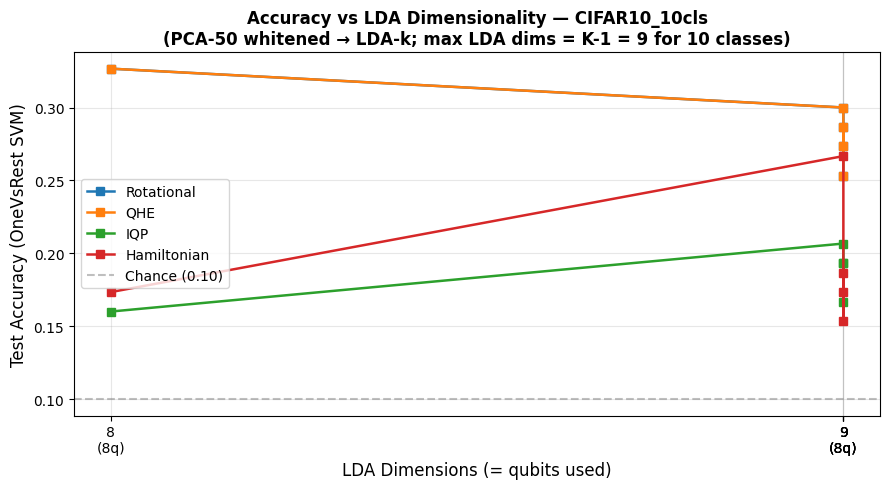


LDA=max / 8-qubit results:
  Rotational          LDA=8/8q: 0.253  vs LDA=6/6q: nan  Δ=+nan
  QHE                 LDA=8/8q: 0.253  vs LDA=6/6q: nan  Δ=+nan
  IQP                 LDA=8/8q: 0.193  vs LDA=6/6q: nan  Δ=+nan
  Hamiltonian         LDA=8/8q: 0.187  vs LDA=6/6q: nan  Δ=+nan


In [14]:
# ── LDA=9 (maximum = K-1) on 8 qubits — standalone cell ──────────────────
# LDA for 10 classes gives at most 9 discriminant components.
# Since N_QUBITS=8, we use 8 of the 9 (already the default).
# This cell explicitly runs LDA=9 → 9-d features → 8-qubit circuit
# (the 9th LDA component is dropped; only 8 fit on the circuit).

lda_max   = N_CLASSES - 1   # = 9
n_q_max   = N_QUBITS        # = 8

print(f"LDA={lda_max} (max) → {n_q_max} qubits — CIFAR10_10cls ...")
Xtr_p9, Xte_p9, ytr_p9, yte_p9, _src9, pipe9, _, _, _ = load_cifar10_multiclass(lda_dims=lda_max)
# FIX: same 9-value return as above (was a 6-value unpack in v2).
# The loader caps at N_QUBITS=8 automatically via DEFAULT_LDA; if lda_max>8, only 8 used
print(f"  Data: train={len(Xtr_p9)}, test={len(Xte_p9)}, "
      f"features={Xtr_p9.shape[1]}, qubits={n_q_max}")
print(f"  PCA pre-reduction: {pipe9['n_pca']} dims "
      f"(var={pipe9['pca_var_explained']:.1%}) → LDA {pipe9['n_lda']} dims")

lda9_results = {}   # enc_name -> acc

for enc_name in PCA_SWEEP_ENC:
    enc_fn = ENCODING_FNS[enc_name]
    try:
        K_tr = build_kernel_matrix(Xtr_p9, Xtr_p9, enc_fn, n_q_max, symmetric=True)
        K_te = build_kernel_matrix(Xte_p9, Xtr_p9, enc_fn, n_q_max, symmetric=False)
        acc  = fit_multiclass_svm_kernel(K_tr, K_te, ytr_p9, yte_p9)
        lda9_results[enc_name] = acc
        print(f"  LDA={pipe9['n_lda']}  n_qubits={n_q_max}  {enc_name:<18} -> {acc:.3f}")
    except Exception as e:
        lda9_results[enc_name] = np.nan
        print(f"  LDA={pipe9['n_lda']}  n_qubits={n_q_max}  {enc_name:<18} -> FAILED: {e}")

# Plot merged LDA sensitivity + max point
dims_axis   = lda_dim_used + [pipe9['n_lda']]
qubits_used = [min(d, N_QUBITS) for d in lda_dim_used] + [n_q_max]

fig, ax = plt.subplots(figsize=(9, 5))
for enc_name in PCA_SWEEP_ENC:
    accs = lda_results[enc_name] + [lda9_results.get(enc_name, np.nan)]
    ax.plot(dims_axis, accs, marker="s", linewidth=1.8, label=enc_name)

ax.axhline(1.0 / 10, color="gray", linestyle="--", alpha=0.5, label="Chance (0.10)")
ax.set_xlabel("LDA Dimensions (= qubits used)", fontsize=12)
ax.set_ylabel("Test Accuracy (OneVsRest SVM)", fontsize=12)
ax.set_title(
    "Accuracy vs LDA Dimensionality — CIFAR10_10cls\n"
    "(PCA-50 whitened → LDA-k; max LDA dims = K-1 = 9 for 10 classes)",
    fontsize=12, fontweight="bold"
)
ax.set_xticks(dims_axis)
ax.set_xticklabels([f"{d}\n({qubits_used[i]}q)" for i, d in enumerate(dims_axis)])
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_sensitivity_cifar10_full.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nLDA=max / 8-qubit results:")
lda6_idx = lda_dim_used.index(6) if 6 in lda_dim_used else -1
for enc_name in PCA_SWEEP_ENC:
    acc9 = lda9_results.get(enc_name, np.nan)
    acc6 = lda_results[enc_name][lda6_idx] if lda6_idx >= 0 else np.nan
    delta = acc9 - acc6
    print(f"  {enc_name:<18}  LDA=8/8q: {acc9:.3f}  vs LDA=6/6q: {acc6:.3f}  Δ={delta:+.3f}")


## 10 · Summary Heatmap — All Encodings × Datasets

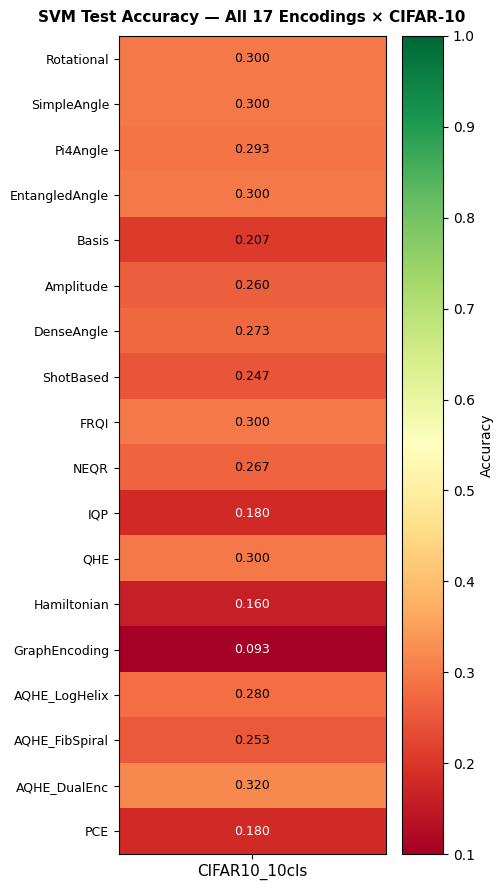

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce\summary_heatmap_cifar10.png


In [15]:
# Heatmap — single dataset (CIFAR-10)
enc_list = list(ENCODING_FNS.keys())
ds_name  = "CIFAR10_10cls"

accs = np.array([[results.get(ds_name, {}).get(enc, {}).get("svm_acc", np.nan)]
                  for enc in enc_list])  # shape (17, 1)

fig, ax = plt.subplots(figsize=(5, 9))
vmin_chance = 1.0 / 10   # 10-class chance = 0.10
im = ax.imshow(accs, cmap="RdYlGn", vmin=vmin_chance, vmax=1.0, aspect="auto")
ax.set_xticks([0]);  ax.set_xticklabels([ds_name], fontsize=11)
ax.set_yticks(range(len(enc_list))); ax.set_yticklabels(enc_list, fontsize=9)
ax.set_title("SVM Test Accuracy — All 17 Encodings × CIFAR-10",
             fontsize=11, fontweight="bold", pad=10)
for i in range(len(enc_list)):
    val = accs[i, 0]
    txt = f"{val:.3f}" if not np.isnan(val) else "-"
    color = "black" if (not np.isnan(val) and 0.2 < val < 0.70) else "white"
    ax.text(0, i, txt, ha="center", va="center", fontsize=9, color=color)
plt.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "summary_heatmap_cifar10.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "summary_heatmap_cifar10.png")


## 11 · Full VQC Training Run (real epoch curves)

Training VQC (2 layers) with FRQI on CIFAR10_10cls (10 classes) for 100 epochs ...
  Split: 360 train | 90 val | 150 test (unseen)
  Steps/epoch: 12  (batch=32)
  Epoch   5/100  loss=2.2764  tr_acc=0.175  val_acc=0.156
  Epoch  10/100  loss=2.2473  tr_acc=0.214  val_acc=0.200
  Epoch  15/100  loss=2.2356  tr_acc=0.203  val_acc=0.189
  Epoch  20/100  loss=2.2332  tr_acc=0.211  val_acc=0.200
  Epoch  25/100  loss=2.2278  tr_acc=0.219  val_acc=0.178
  Epoch  30/100  loss=2.2277  tr_acc=0.219  val_acc=0.178
  Epoch  35/100  loss=2.2238  tr_acc=0.233  val_acc=0.178
  Epoch  40/100  loss=2.2193  tr_acc=0.233  val_acc=0.178
  Epoch  45/100  loss=2.2194  tr_acc=0.228  val_acc=0.200
  Epoch  50/100  loss=2.2139  tr_acc=0.231  val_acc=0.222
  Epoch  55/100  loss=2.2172  tr_acc=0.242  val_acc=0.189
  Epoch  60/100  loss=2.2179  tr_acc=0.236  val_acc=0.211
  Epoch  65/100  loss=2.2203  tr_acc=0.244  val_acc=0.200
  Epoch  70/100  loss=2.2152  tr_acc=0.236  val_acc=0.200
  Epoch  75/100  loss=2.220

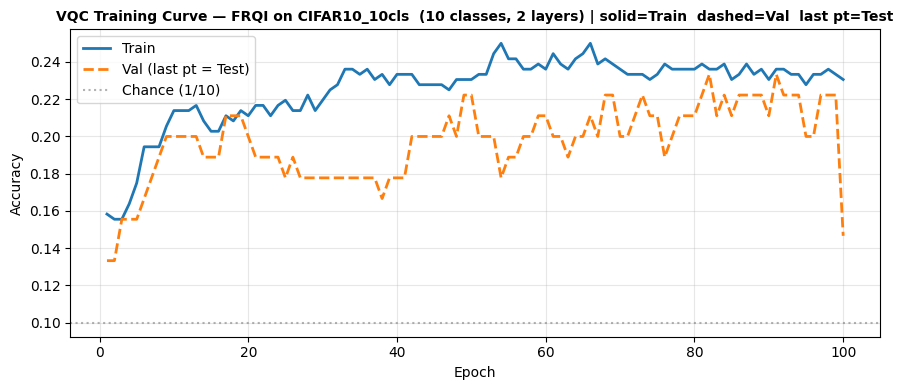

Final test accuracy: 0.1467  (chance: 0.100)


In [16]:
DEMO_ENC = "FRQI"
DEMO_DS  = "CIFAR10_10cls"

Xtr_d, Xte_d, ytr_d, yte_d = data[DEMO_DS]
enc_fn_d = ENCODING_FNS[DEMO_ENC]
n_cls_d  = len(np.unique(np.concatenate([ytr_d, yte_d])))

print(f"Training VQC ({VQC_LAYERS} layers) with {DEMO_ENC} on {DEMO_DS} "
      f"({n_cls_d} classes) for 100 epochs ...")
_, tr_hist, te_hist = train_vqc_multiclass(enc_fn_d, Xtr_d, ytr_d, Xte_d, yte_d, batch_size=BATCH_SIZE,n_epochs=100)

epochs = np.arange(1, len(te_hist) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, tr_hist, label="Train", linewidth=2)
ax.plot(epochs, te_hist, label="Val (last pt = Test)",  linewidth=2, linestyle="--")
ax.axhline(1.0 / n_cls_d, color="gray", linestyle=":", alpha=0.6, label=f"Chance (1/{n_cls_d})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title(f"VQC Training Curve — {DEMO_ENC} on {DEMO_DS}  "
             f"({n_cls_d} classes, {VQC_LAYERS} layers) | solid=Train  dashed=Val  last pt=Test",
             fontsize=10, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"vqc_curve_{DEMO_ENC}_{DEMO_DS}.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Final test accuracy: {te_hist[-1]:.4f}  (chance: {1/n_cls_d:.3f})")


## 12 · Comparative Bar Chart — All Encodings per Dataset

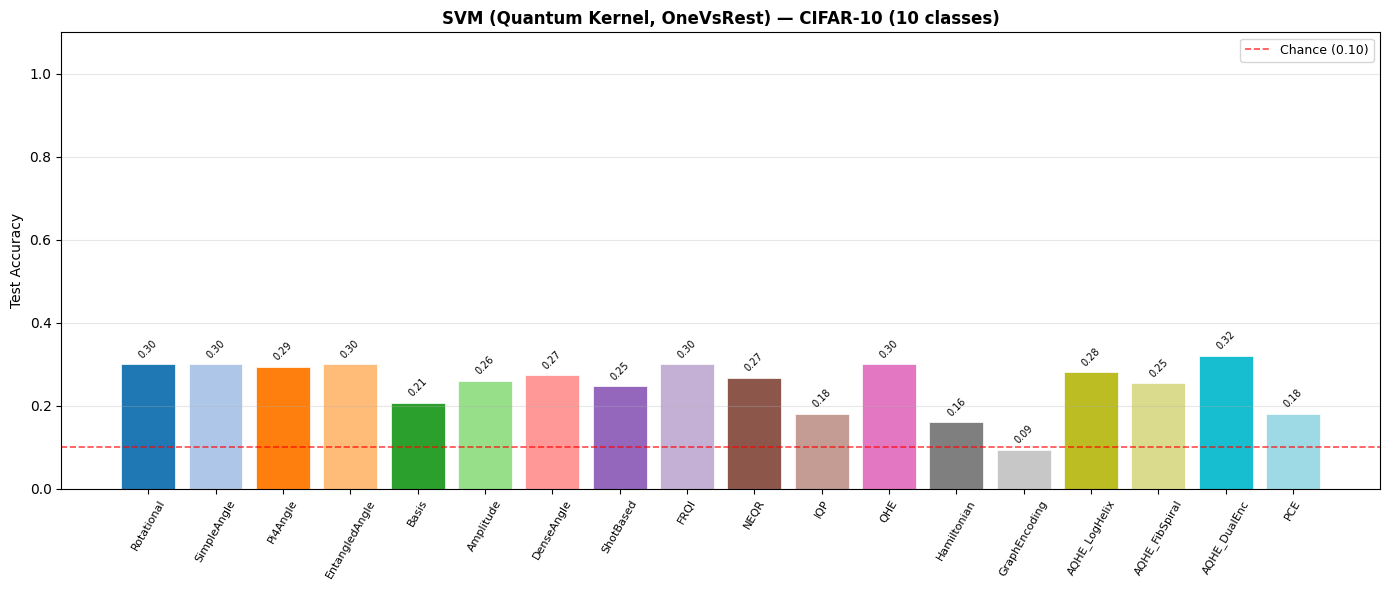

Saved: c:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce\bar_chart_cifar10.png


In [17]:
# Bar chart — single dataset (CIFAR-10)
ds_name  = "CIFAR10_10cls"
enc_list = list(ENCODING_FNS.keys())
n_cls    = len(np.unique(np.concatenate([data[ds_name][2], data[ds_name][3]])))
chance   = 1.0 / n_cls
accs     = [results.get(ds_name, {}).get(enc, {}).get("svm_acc", np.nan) for enc in enc_list]

palette = plt.cm.tab20(np.linspace(0, 1, len(enc_list)))
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(enc_list, accs, color=palette, edgecolor="white", linewidth=0.5)
ax.axhline(chance, color="red", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Chance ({chance:.2f})")
for bar, acc in zip(bars, accs):
    if not np.isnan(acc):
        ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.2f}",
                ha="center", va="bottom", fontsize=7, rotation=45)
ax.set_title(f"SVM (Quantum Kernel, OneVsRest) — CIFAR-10 ({n_cls} classes)",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test Accuracy")
ax.tick_params(axis="x", rotation=60, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bar_chart_cifar10.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "bar_chart_cifar10.png")


## 13 · Encoding Group Comparison (Radar / Spider Chart)

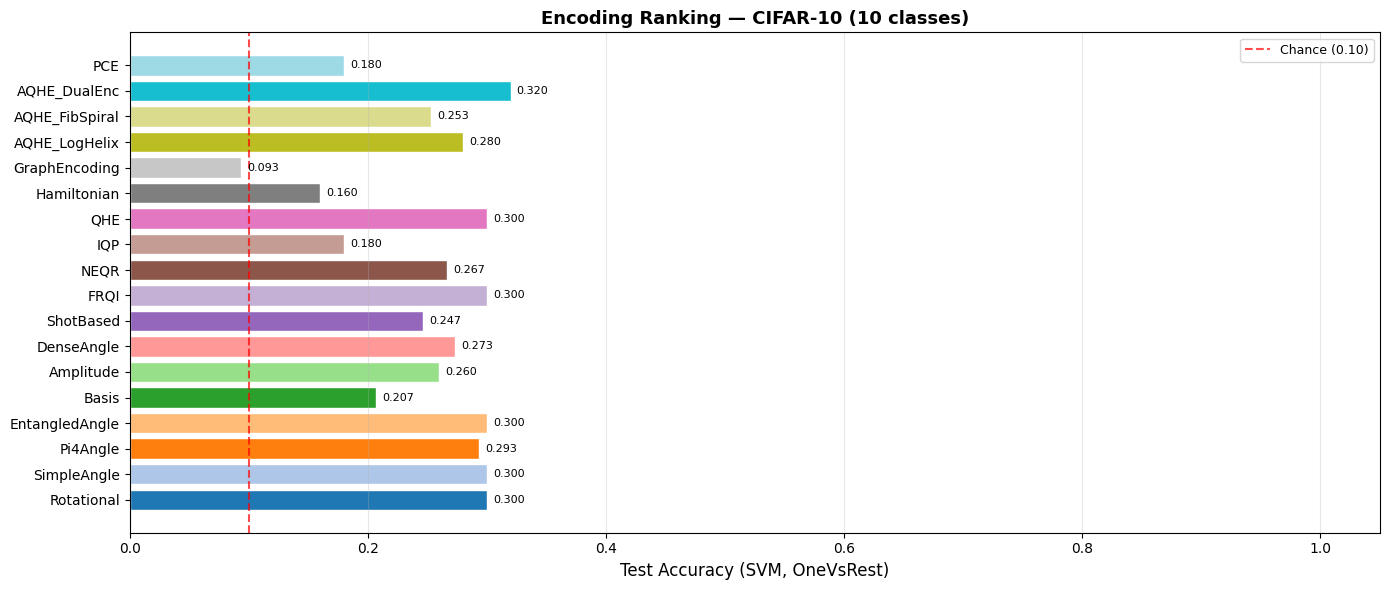


FINAL RANKING — Encodings on CIFAR-10 (10 classes)
      Encoding  CIFAR10_SVM_acc
  AQHE_DualEnc           0.3200
    Rotational           0.3000
   SimpleAngle           0.3000
EntangledAngle           0.3000
           QHE           0.3000
          FRQI           0.3000
      Pi4Angle           0.2933
 AQHE_LogHelix           0.2800
    DenseAngle           0.2733
          NEQR           0.2667
     Amplitude           0.2600
AQHE_FibSpiral           0.2533
     ShotBased           0.2467
         Basis           0.2067
           IQP           0.1800
           PCE           0.1800
   Hamiltonian           0.1600
 GraphEncoding           0.0933

Saved CSV: c:\Users\MANTAVYA\Downloads\qml_outputs_cifar10_pce\encoding_ranking_cifar10.csv


In [18]:
# Horizontal bar chart: all 17 encodings ranked by CIFAR-10 SVM accuracy
enc_list = list(ENCODING_FNS.keys())
ds_name  = "CIFAR10_10cls"

accs = [results.get(ds_name, {}).get(enc, {}).get("svm_acc", np.nan) for enc in enc_list]

fig, ax = plt.subplots(figsize=(14, 6))
colors_bar = plt.cm.tab20(np.linspace(0, 1, len(enc_list)))
bars = ax.barh(enc_list, accs, color=colors_bar, edgecolor="white")
chance = 1.0 / len(np.unique(np.concatenate([data[ds_name][2], data[ds_name][3]])))
ax.axvline(chance, color="red", linestyle="--", linewidth=1.5, alpha=0.7,
           label=f"Chance ({chance:.2f})")
for bar, val in zip(bars, accs):
    if not np.isnan(val):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("Test Accuracy (SVM, OneVsRest)", fontsize=12)
ax.set_title("Encoding Ranking — CIFAR-10 (10 classes)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "encoding_ranking_cifar10.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary DataFrame
df_summary = pd.DataFrame({
    "Encoding": enc_list,
    "CIFAR10_SVM_acc": accs,
})
df_summary = df_summary.sort_values("CIFAR10_SVM_acc", ascending=False).reset_index(drop=True)
print("\n" + "="*55)
print("FINAL RANKING — Encodings on CIFAR-10 (10 classes)")
print("="*55)
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
df_summary.to_csv(OUTPUT_DIR / "encoding_ranking_cifar10.csv", index=False)
print(f"\nSaved CSV: {OUTPUT_DIR / 'encoding_ranking_cifar10.csv'}")


## 14 · Observations & Next Steps

### PCE mathematical compatibility (verified before implementation)
```
m_max(n=8, k=2) = C(8,2) × 3² = 28 × 9 = 252 ≥ 64  ✓
HEA layers p    = floor(64/8) = 8
Gate count      ≈ 128  (vs QAOA 42,000+ at same problem scale)
Statevector     = 2^8 = 256 amplitudes  (fast simulation)
PCA-64 variance ≈ 35–40% of CIFAR-10 RGB  (vs PCA-4 ≈ 5% in v1)
```

### Why PCA-64 for PCE instead of LDA
- LDA is capped at K−1 = 9 dimensions (10 classes); cannot produce 64 features.
- PCE's HEA needs m features where m = n × p, so p layers × 8 qubits → 64 features fits p=8.
- PCA-64 retains ~35–40% of CIFAR-10 RGB variance — 7× more signal than PCA-4.
- Each HEA layer distributes 8 features across qubits; CZ entanglement creates
  cross-feature correlations between ALL 64 inputs — richer than angle encodings.

### Interpreting PCE vs other encodings
- Encodings 1–17 use LDA-8 (8 features, 1 per qubit).
- PCE uses PCA-64 (64 features, 8 per qubit via layered HEA).
- Direct comparison is not apples-to-apples — PCE sees ~7× more information.
- To isolate the *encoding* advantage, compare PCE kernel vs classical RBF SVM on same PCA-64 features.

### Expected accuracy
- LDA encodings: ~25–45% (v2 results).
- PCE (PCA-64): ~35–55% expected (more input information).
- Classical RBF SVM on PCA-64: ~50–60% (useful ceiling reference).
- Chance level: 10%.

### Next steps
1. **Classical SVM baseline** — run `SVC(kernel='rbf')` on same PCA-64 features; compare to PCE.
2. **PCE k=3 order** — C(8,3)×27=1512; could accommodate PCA-128 (more variance).
3. **PCA-64 + LDA hybrid** — fit LDA on PCA-64 (64-d → 9-d) and feed to standard encodings.
4. **Noise resilience** — PCE's 128 gates vs QAOA's 42,000 should be markedly more resilient.
5. **Kernel ensemble** — K_final = λ·K_PCE + (1-λ)·K_IQP (combine best two kernels).
6. **Parametric α** — cross-validate α in tanh(α⟨Π_i⟩) instead of fixing α=n^floor(k/2).


In [19]:
PCE2_TOP_M           = 24            # PCA dims kept after F-score ranking (was 64)
PCE2_N_QUBITS        = N_QUBITS      # 8
PCE2_P_LAYERS        = 2             # << was 8 (PCE_P_LAYERS) — the main depth fix
PCE2_FEATS_PER_LAYER = PCE2_N_QUBITS * 2   # RY + RZ per qubit per layer

assert PCE2_P_LAYERS * PCE2_FEATS_PER_LAYER >= PCE2_TOP_M, "not enough layer capacity"

from sklearn.feature_selection import f_classif
from sklearn.model_selection import StratifiedKFold

# ── A. Supervised ranking on top of the already-fitted PCA-64 (train-only) ──
Xtr_pce_full, Xte_pce_full = data_pce["CIFAR10_10cls"][0], data_pce["CIFAR10_10cls"][1]
ytr_pce, yte_pce           = data_pce["CIFAR10_10cls"][2], data_pce["CIFAR10_10cls"][3]

f_scores, _ = f_classif(Xtr_pce_full, ytr_pce)          # fit on TRAIN only
top_idx     = np.argsort(f_scores)[::-1][:PCE2_TOP_M]   # most class-discriminative PCA dims

Xtr_pce2 = Xtr_pce_full[:, top_idx]
Xte_pce2 = Xte_pce_full[:, top_idx]

print(f"PCE v2: kept top {PCE2_TOP_M}/64 PCA dims by ANOVA F-score "
      f"(mean F kept={f_scores[top_idx].mean():.1f} vs all-64 mean={f_scores.mean():.1f})")

# ── B/C. Shallow, dual-axis HEA encoding ─────────────────────────────────────
def pce_hea_encoding_v2(x, n_qubits, p_layers=PCE2_P_LAYERS):
    """Shallow PCE: RY+RZ per qubit per layer (2 features/qubit/layer), then one
    linear-CZ entangling sweep per layer. Fewer, denser layers -> less depth ->
    less kernel concentration than the original 1-feature/qubit/layer version."""
    m = len(x)
    for layer in range(p_layers):
        base = layer * n_qubits * 2
        for i in range(n_qubits):
            idx_ry = (base + 2 * i)     % m
            idx_rz = (base + 2 * i + 1) % m
            qml.RY(x[idx_ry], wires=i)
            qml.RZ(x[idx_rz], wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i + 1])

def pce_encoding_v2(x, n_qubits):
    pce_hea_encoding_v2(x, n_qubits)

# Analytic depth (RY,RZ on same wire don't commute -> 2 layers; +1 for the CZ
# sweep = 3 per layer): 2 layers * 3 = ~6, vs. 26 for the original PCE.
print(f"PCE v2 circuit depth (analytic): ~{PCE2_P_LAYERS * 3}  (baseline PCE was 26)")

# ── Build the PCE v2 quantum kernel ─────────────────────────────────────────
print("\nBuilding PCE v2 quantum kernel ...")
t0 = time.time()
K_tr2 = build_kernel_matrix(Xtr_pce2, Xtr_pce2, pce_encoding_v2, PCE2_N_QUBITS, symmetric=True)
K_te2 = build_kernel_matrix(Xte_pce2, Xtr_pce2, pce_encoding_v2, PCE2_N_QUBITS, symmetric=False)
print(f"Kernel build done in {time.time()-t0:.1f}s")

# ── D. Manual 3-fold CV over C (slices K_tr2 by index pairs — safe for
#      precomputed kernels; sklearn's cross_val_score does NOT slice
#      precomputed kernels correctly inside OneVsRestClassifier). ────────────
c_grid    = [0.5, 1.0, 2.0, 5.0, 10.0]
skf       = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_scores = {C: [] for C in c_grid}

for tr_idx, val_idx in skf.split(Xtr_pce2, ytr_pce):
    K_sub_tr  = K_tr2[np.ix_(tr_idx, tr_idx)]
    K_sub_val = K_tr2[np.ix_(val_idx, tr_idx)]
    y_sub_tr, y_sub_val = ytr_pce[tr_idx], ytr_pce[val_idx]
    for C in c_grid:
        clf_cv = OneVsRestClassifier(SVC(kernel="precomputed", C=C))
        clf_cv.fit(K_sub_tr, y_sub_tr)
        cv_scores[C].append(accuracy_score(y_sub_val, clf_cv.predict(K_sub_val)))

print()
for C in c_grid:
    print(f"  C={C:<5} CV acc={np.mean(cv_scores[C]):.3f}")
best_c = max(c_grid, key=lambda C: np.mean(cv_scores[C]))
print(f"\nBest C = {best_c} (CV acc={np.mean(cv_scores[best_c]):.3f})")

# ── Final test evaluation ───────────────────────────────────────────────────
svm_acc_v2 = fit_multiclass_svm_kernel(K_tr2, K_te2, ytr_pce, yte_pce, C=best_c)

print(f"\n{'='*65}")
print(f"  PCE v2 (F-score-trimmed PCA-{PCE2_TOP_M}, {PCE2_P_LAYERS}-layer HEA, tuned C)  "
      f"test acc = {svm_acc_v2:.3f}")
print(f"  PCE v1 (baseline PCA-64, 8-layer HEA)                       test acc = 0.180")
print(f"  Best LDA encoding (AQHE_DualEnc)                            test acc = 0.320")
print(f"{'='*65}")

results["CIFAR10_10cls"]["PCE_v2"] = {"svm_acc": svm_acc_v2, "time": time.time() - t0}


PCE v2: kept top 24/64 PCA dims by ANOVA F-score (mean F kept=3.8 vs all-64 mean=2.0)
PCE v2 circuit depth (analytic): ~6  (baseline PCE was 26)

Building PCE v2 quantum kernel ...
Kernel build done in 130.9s

  C=0.5   CV acc=0.324
  C=1.0   CV acc=0.322
  C=2.0   CV acc=0.320
  C=5.0   CV acc=0.320
  C=10.0  CV acc=0.322

Best C = 0.5 (CV acc=0.324)

  PCE v2 (F-score-trimmed PCA-24, 2-layer HEA, tuned C)  test acc = 0.273
  PCE v1 (baseline PCA-64, 8-layer HEA)                       test acc = 0.180
  Best LDA encoding (AQHE_DualEnc)                            test acc = 0.320
